# SegmentIG0.1 soft metrics for patch success

Минимальный ноутбук для расчёта и сравнения новых soft-вариантов `delta_energy_in_importance_top` только для `SegmentIG[0;0.1]`.


## Настройка и кеш атаки

Инициализируем эксперимент и загружаем или строим кеш атак, который нужен для расчёта success/fail метрик.


In [3]:
from pathlib import Path
import sys

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import pandas as pd
from IPython.display import Image, display

from patch_success_analysis.notebook_setup import (
    ensure_new_experiments_cwd,
    load_segmentig_success_failure_rows,
    make_celeb_patch_success_experiment,
    resolve_existing_path,
)

cwd = ensure_new_experiments_cwd()
attack_config, config, exp = make_celeb_patch_success_experiment()
print(f"cwd={cwd}")
print(f"attack cache key={attack_config.cache_key()}")
print(f"attack cache path={attack_config.cache_path}")
cache = exp.build_or_load_cache(force=False)


## Расчёт SegmentIG-only метрик

`run_segmentig_success_failure_metrics()` считает только метрики на основе `SegmentIG[0;0.1]` и `Δ`. Карты слоя (`delta_chw`, `segmentig_chw`, `clean_activation_chw`) отдельно кэшируются в `cache/layer_maps/*.npz`, поэтому новые scalar-метрики пересчитываются на основе этих карт без повторного тяжёлого attribution pipeline для уже сохранённых examples. Для принудительного пересчёта scalar rows поставь `force_success_failure_metrics_recompute = True`; для принудительного пересчёта самих layer maps нужно удалить соответствующие `.npz` или обновить version в коде.


In [4]:
force_success_failure_metrics_recompute = False
sf, rows_df, quality_df = load_segmentig_success_failure_rows(
    exp,
    force=force_success_failure_metrics_recompute,
)
print(f"examples={len(rows_df)}, metrics={len(quality_df)}, loaded_from_cache={sf.get('loaded_from_cache')}")
print(sf.get('cache_path'))


examples=6000, metrics=177, loaded_from_cache=False
new_experiments/outputs/patch_success_analysis/cache/segmentig_success_failure_metrics_b1163b3ceaf28fbd.pkl


### SegmentIG0.1 soft-варианты `delta_energy_in_importance_top`

Сравниваем старую бинарную top-5% метрику с двумя product-метриками и binned-метриками. Signed product проверяет гипотезу атаки: если положительно важные нейроны уводятся вниз, а отрицательно важные вверх, то `-A * Δ` становится положительным и большее значение должно соответствовать более успешной атаке.


,metric,family,cutoff_percent,roc_auc,best_accuracy,best_threshold,best_direction
7,segmentig_delta_energy_in_importance_top,baseline_top5_binary,<NA>,0.848267,0.784167,0.066363,1
18,segmentig_delta_energy_importance_bins_top25_exp,exp,25,0.846422,0.783167,0.085777,1
17,segmentig_delta_energy_importance_bins_top25_r...,reciprocal,25,0.846465,0.783000,0.047538,1
19,segmentig_delta_energy_importance_bins_top10_l...,linear,10,0.845917,0.782500,0.066884,1
21,segmentig_delta_energy_importance_bins_top10_exp,exp,10,0.846515,0.781833,0.043864,1
14,segmentig_delta_energy_importance_bins_top50_r...,reciprocal,50,0.846009,0.781667,0.054198,1
15,segmentig_delta_energy_importance_bins_top50_exp,exp,50,0.845840,0.781667,0.155676,1
11,segmentig_delta_energy_importance_bins_top100_...,reciprocal,100,0.845832,0.781667,0.060955,1
10,segmentig_delta_energy_importance_bins_top100_...,linear,100,0.845025,0.781500,0.512122,1
20,segmentig_delta_energy_importance_bins_top10_r...,reciprocal,10,0.845083,0.781167,0.039333,1


success,metric,family,cutoff_percent,fail_mean,success_mean
0,segmentig_delta_energy_in_importance_top,baseline_top5_binary,<NA>,0.056471,0.075959
1,segmentig_delta_importance_product_signed,product_signed,<NA>,0.000069,0.000112
2,segmentig_delta_importance_product_unsigned,product_unsigned,<NA>,0.000786,0.001089
3,segmentig_delta_energy_importance_bins_top100_...,linear,100,0.506687,0.518258
4,segmentig_delta_energy_importance_bins_top100_...,reciprocal,100,0.056041,0.066042
5,segmentig_delta_energy_importance_bins_top100_exp,exp,100,0.286642,0.302071
6,segmentig_delta_energy_importance_bins_top50_l...,linear,50,0.257617,0.274333
7,segmentig_delta_energy_importance_bins_top50_r...,reciprocal,50,0.049181,0.059372
8,segmentig_delta_energy_importance_bins_top50_exp,exp,50,0.147209,0.164353
9,segmentig_delta_energy_importance_bins_top25_l...,linear,25,0.131255,0.149687


segmentig_delta_energy_in_importance_top | roc_auc=0.848 | best_acc=0.784


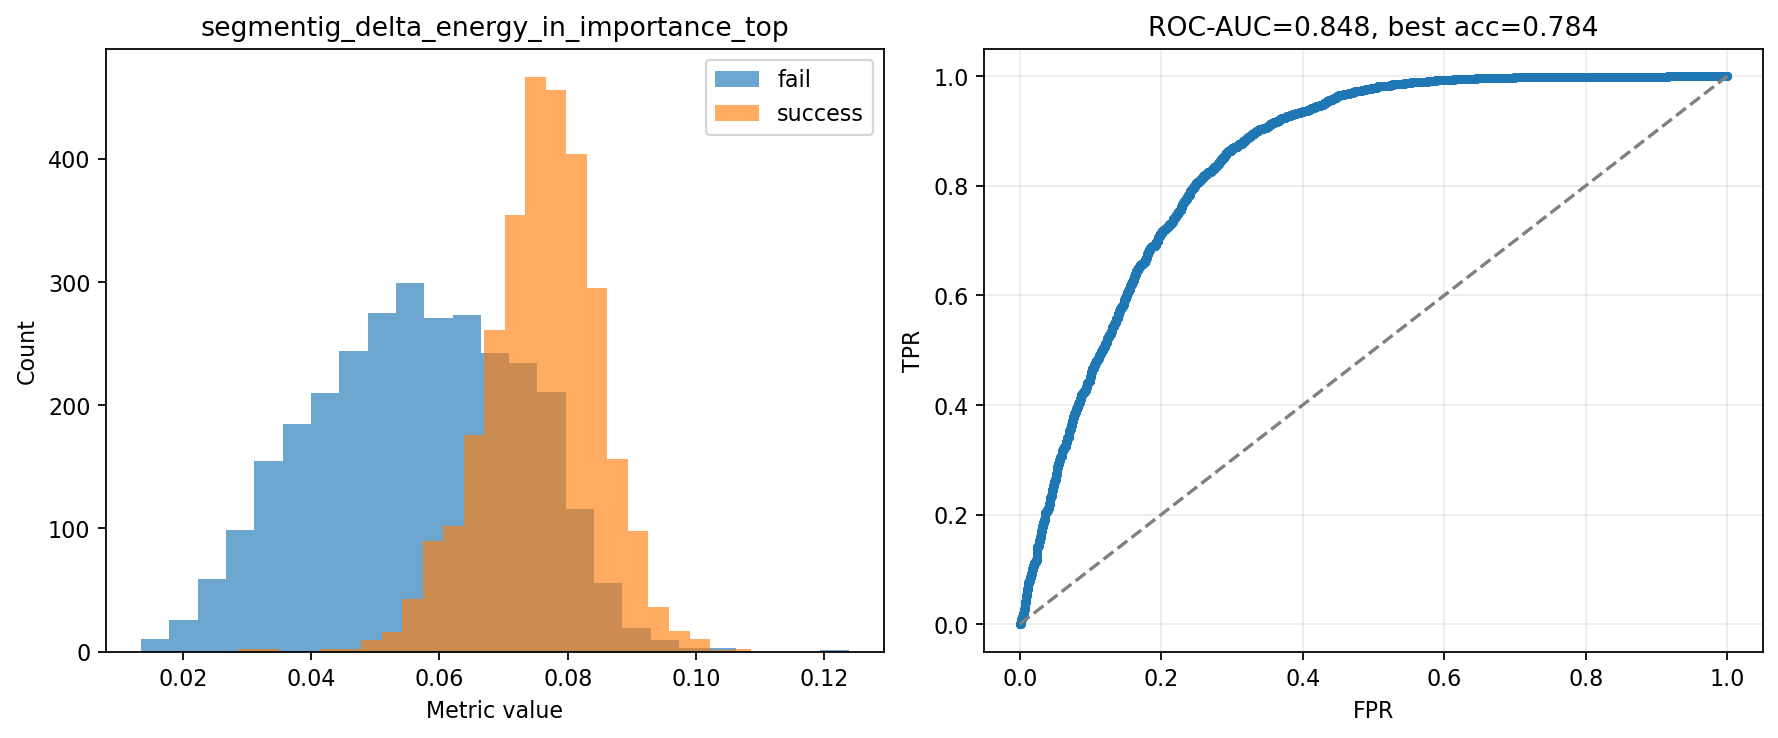

segmentig_delta_energy_importance_bins_top25_exp | roc_auc=0.846 | best_acc=0.783


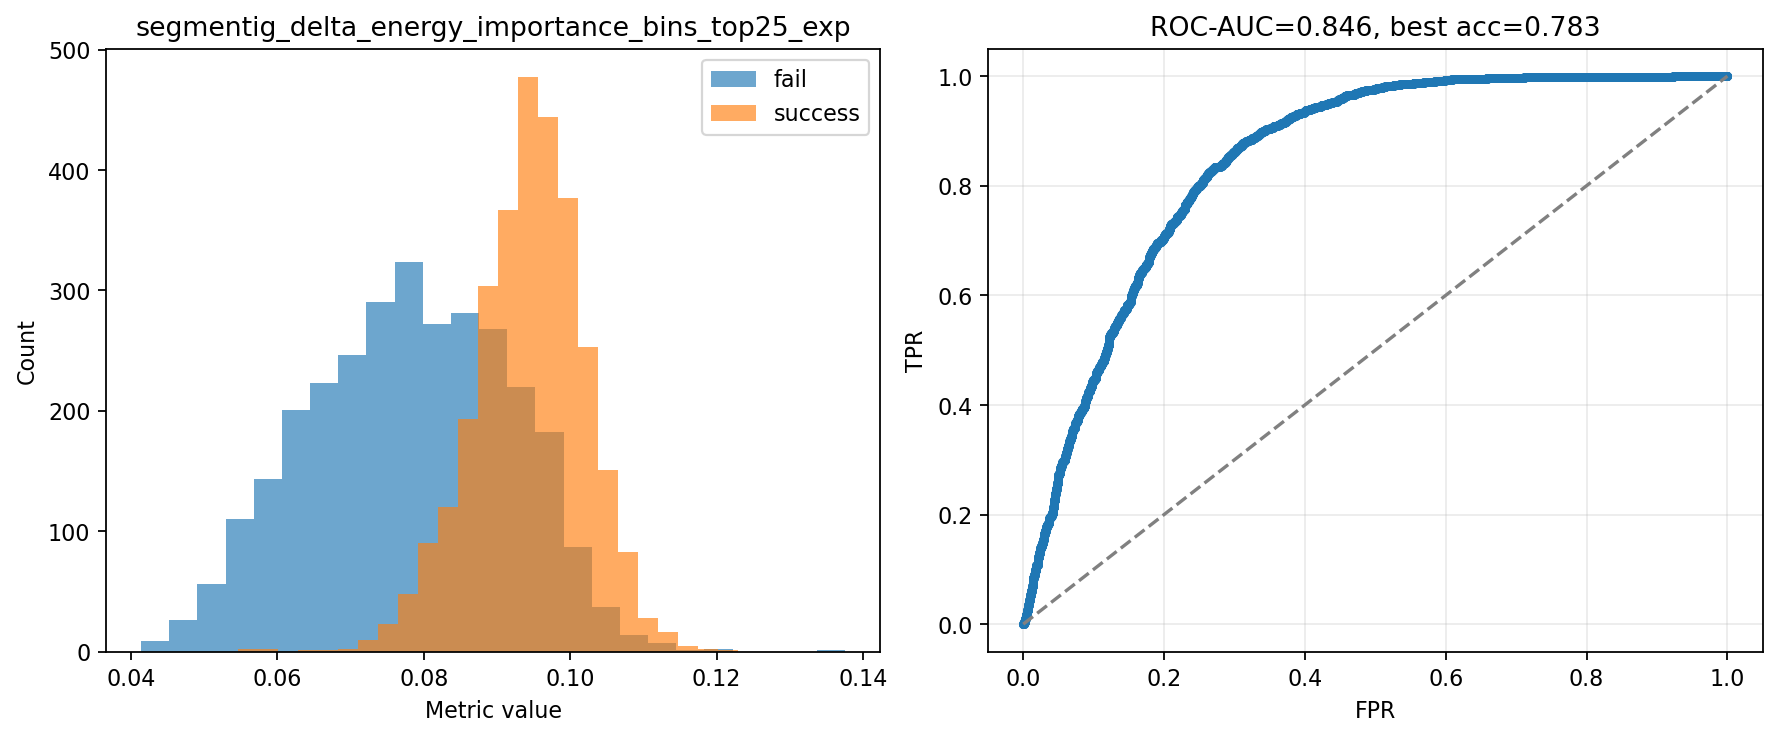

segmentig_delta_energy_importance_bins_top25_reciprocal | roc_auc=0.846 | best_acc=0.783


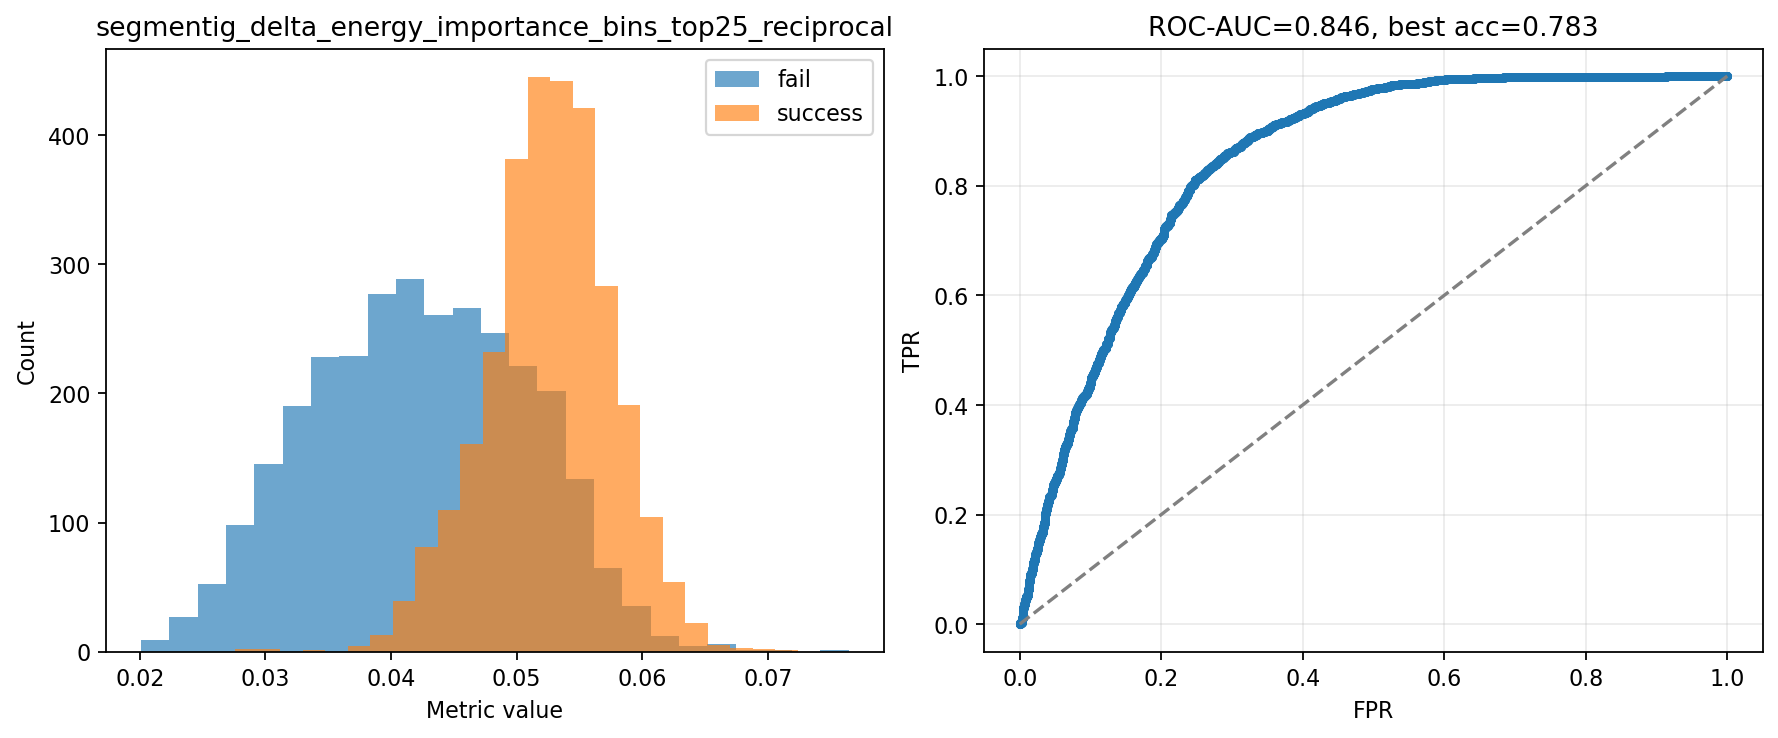

segmentig_delta_energy_importance_bins_top10_linear | roc_auc=0.846 | best_acc=0.782


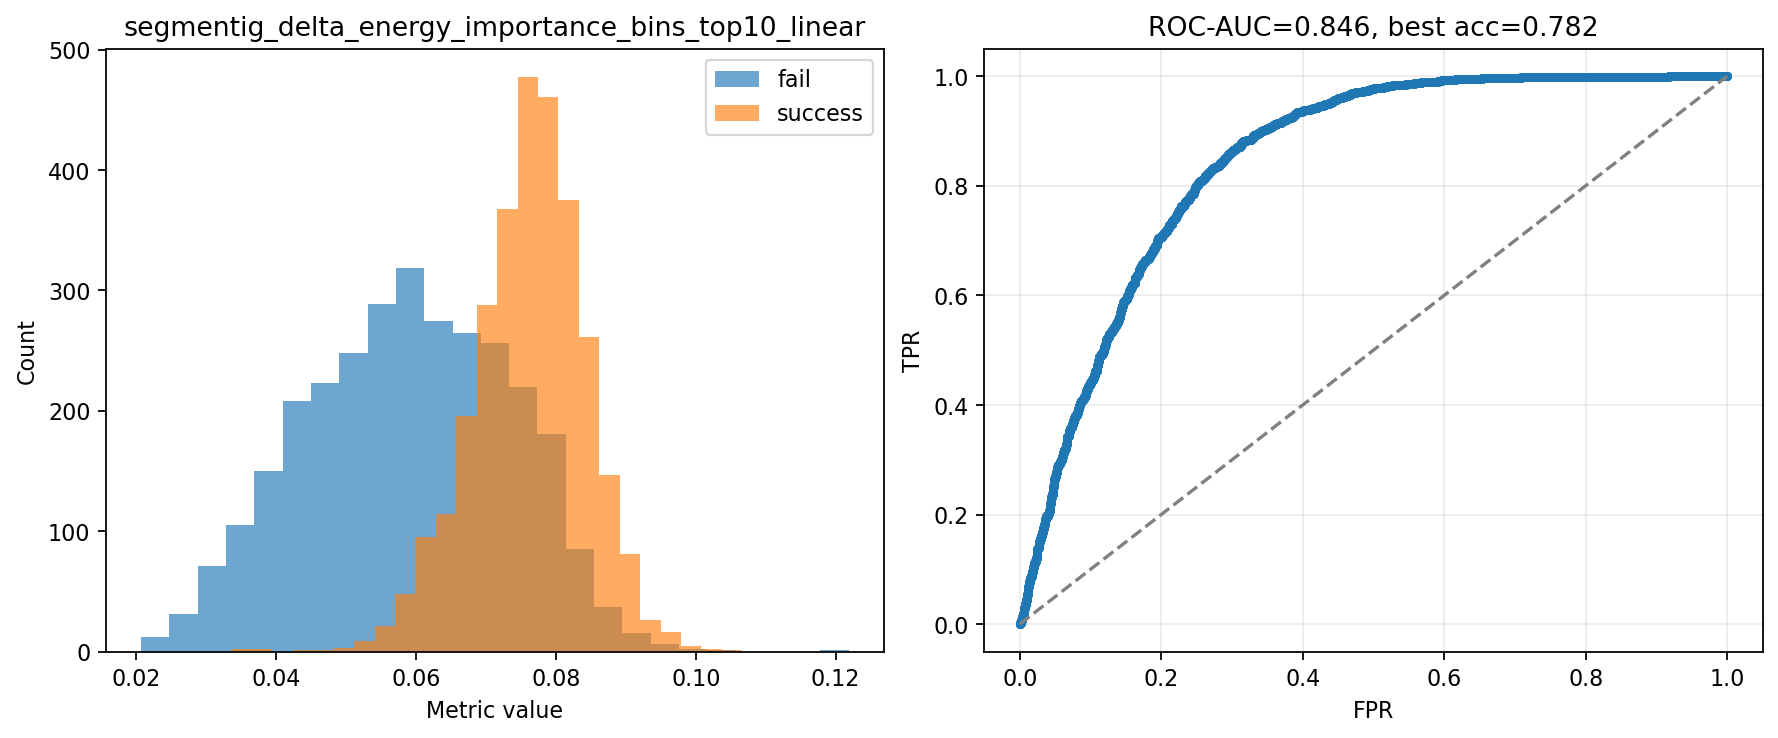

segmentig_delta_energy_importance_bins_top10_exp | roc_auc=0.847 | best_acc=0.782


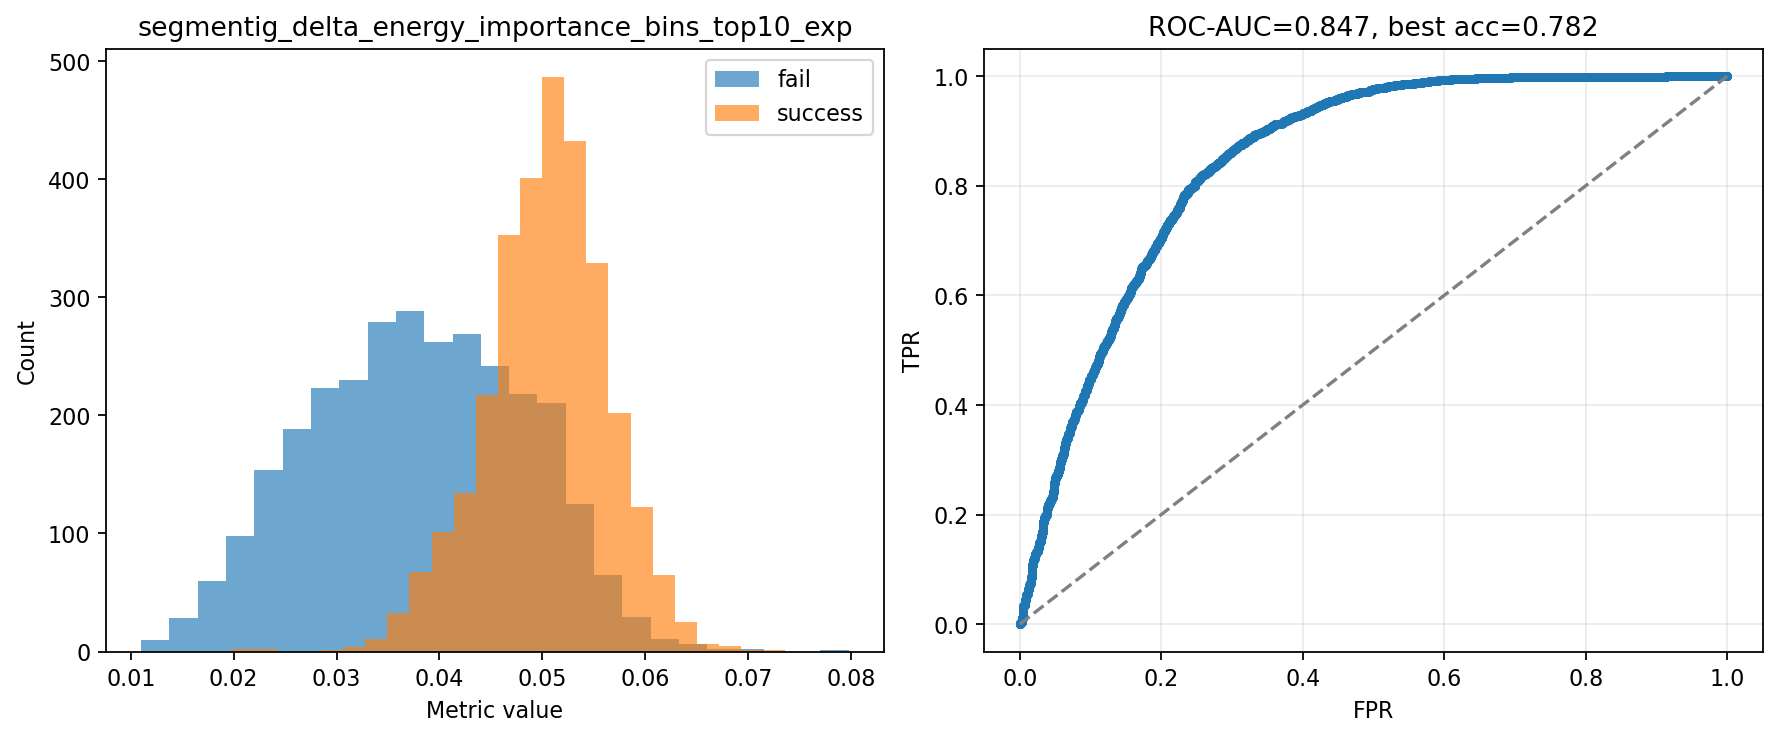

segmentig_delta_energy_importance_bins_top50_reciprocal | roc_auc=0.846 | best_acc=0.782


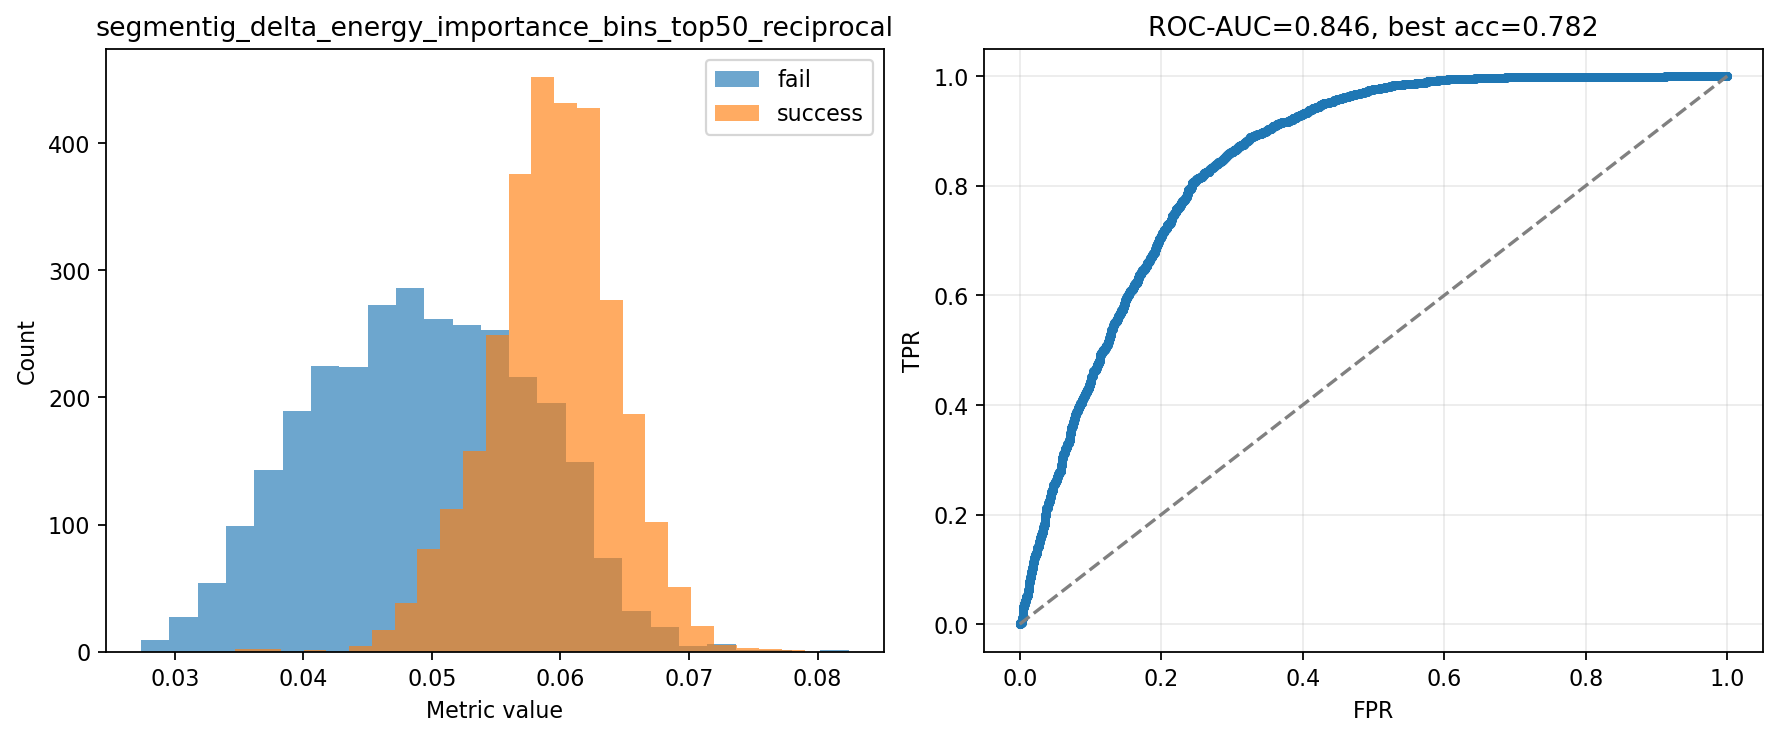

segmentig_delta_energy_importance_bins_top50_exp | roc_auc=0.846 | best_acc=0.782


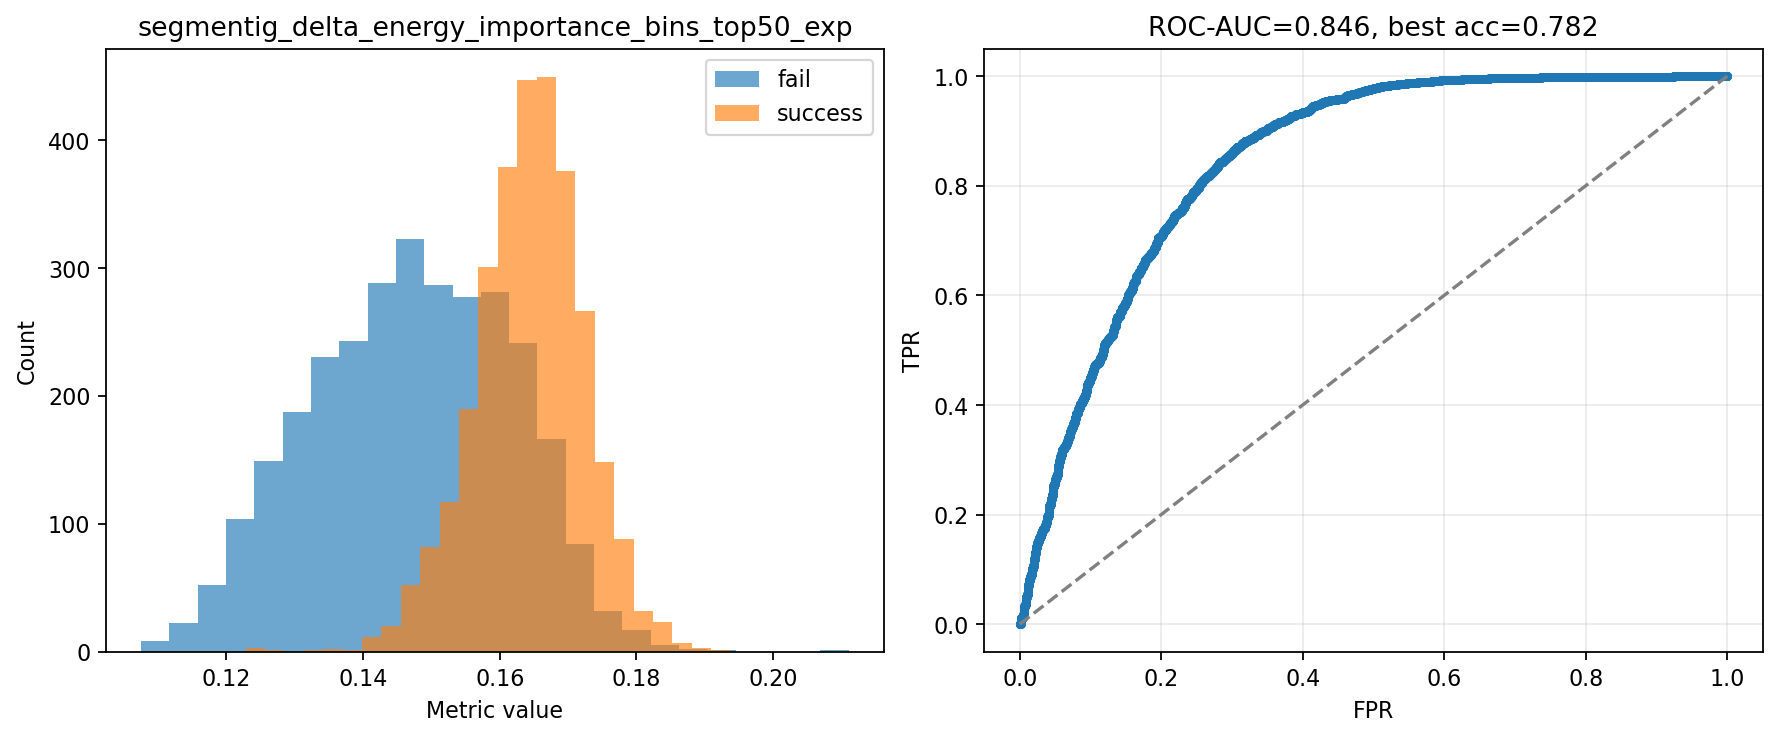

segmentig_delta_energy_importance_bins_top100_reciprocal | roc_auc=0.846 | best_acc=0.782


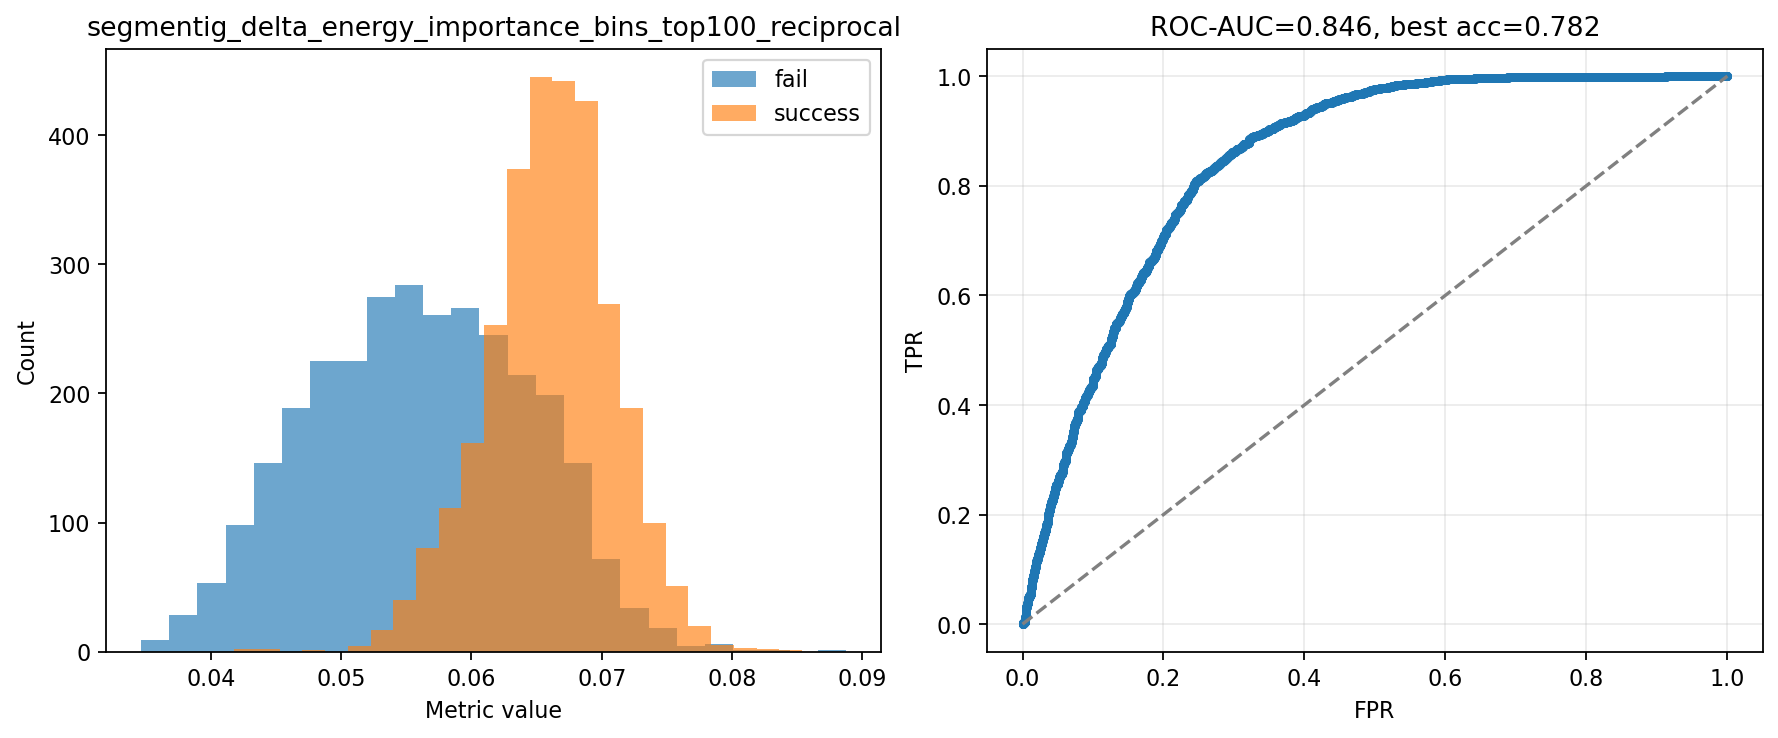

segmentig_delta_energy_importance_bins_top100_linear | roc_auc=0.845 | best_acc=0.781


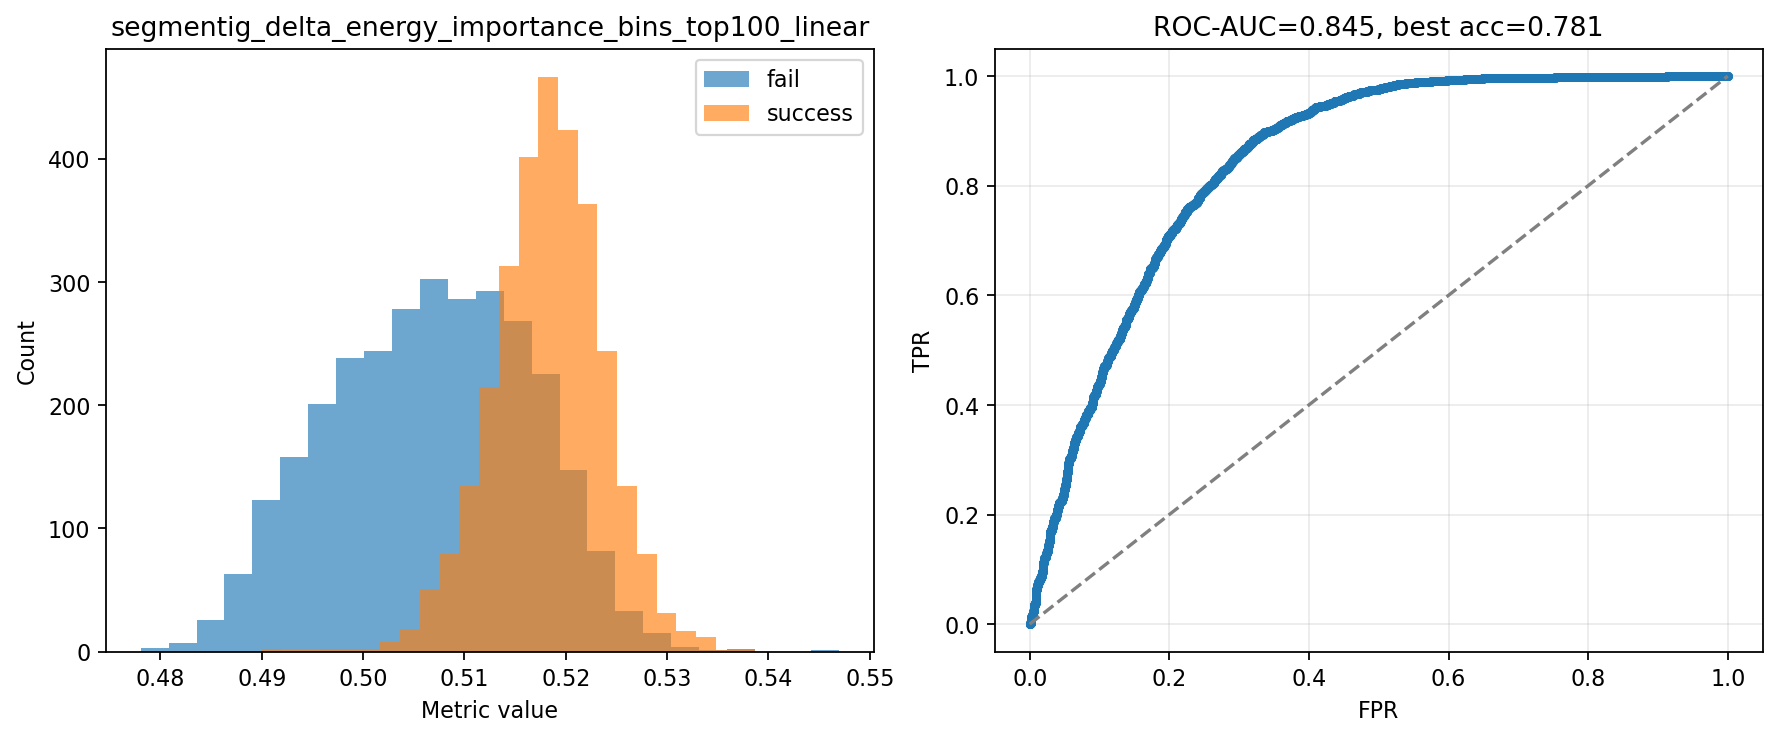

segmentig_delta_energy_importance_bins_top10_reciprocal | roc_auc=0.845 | best_acc=0.781


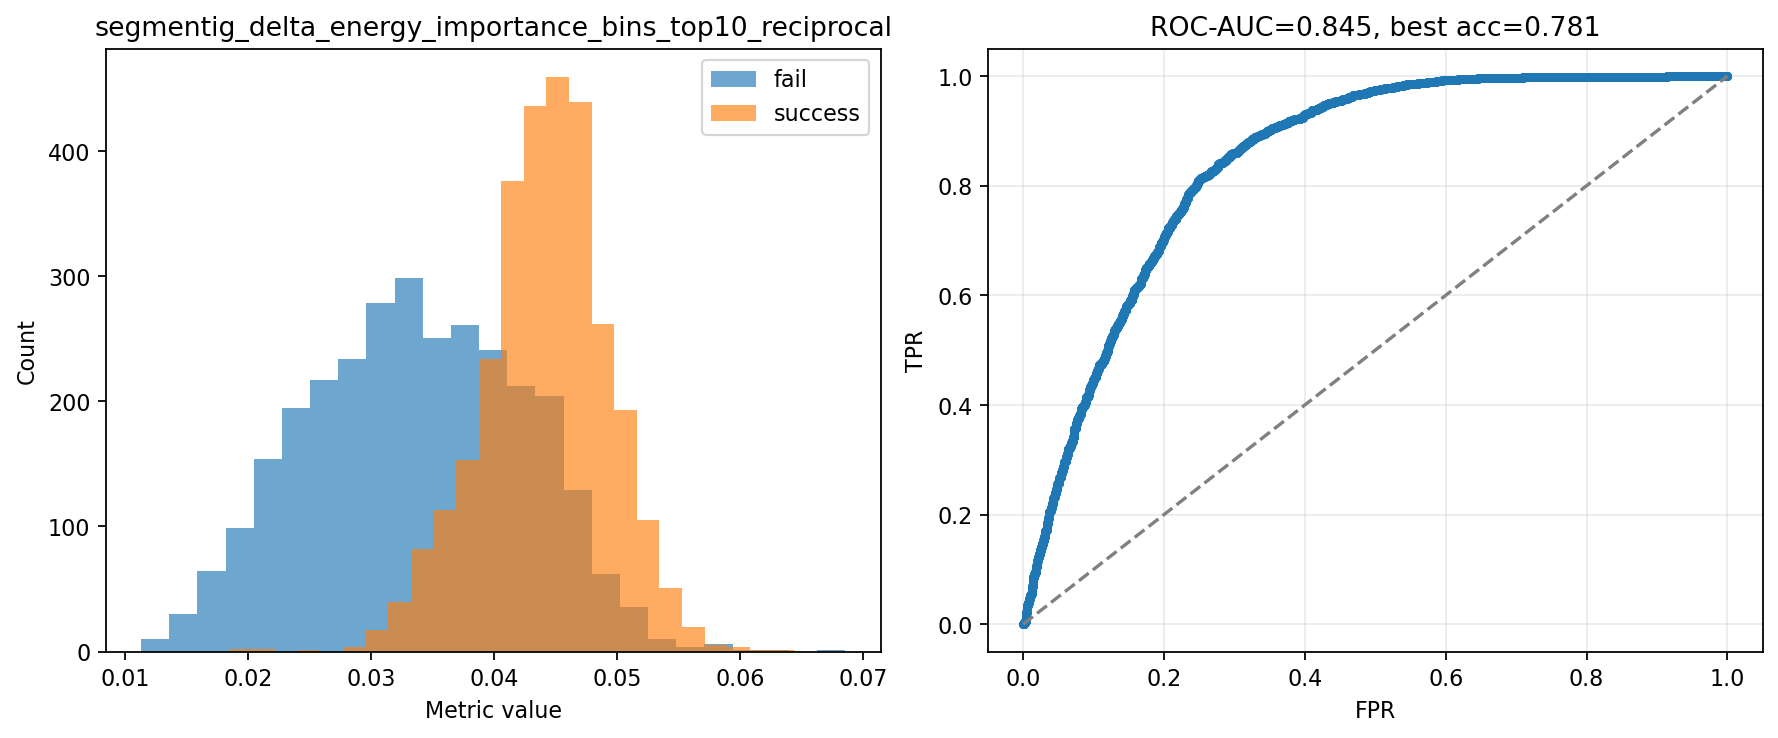

segmentig_delta_energy_importance_bins_top100_exp | roc_auc=0.846 | best_acc=0.781


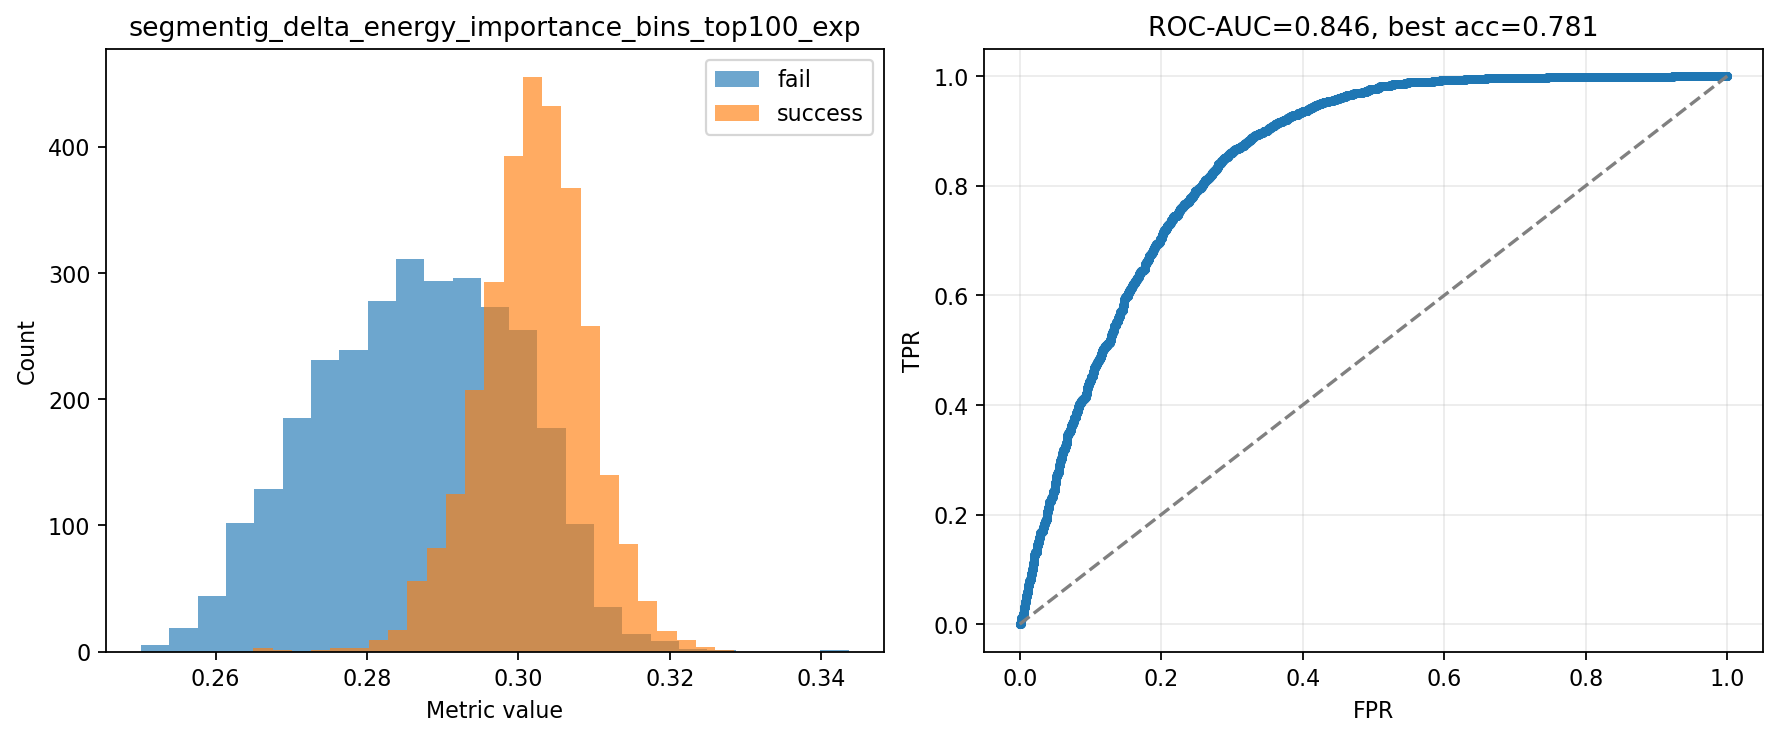

segmentig_delta_energy_importance_bins_top25_linear | roc_auc=0.845 | best_acc=0.781


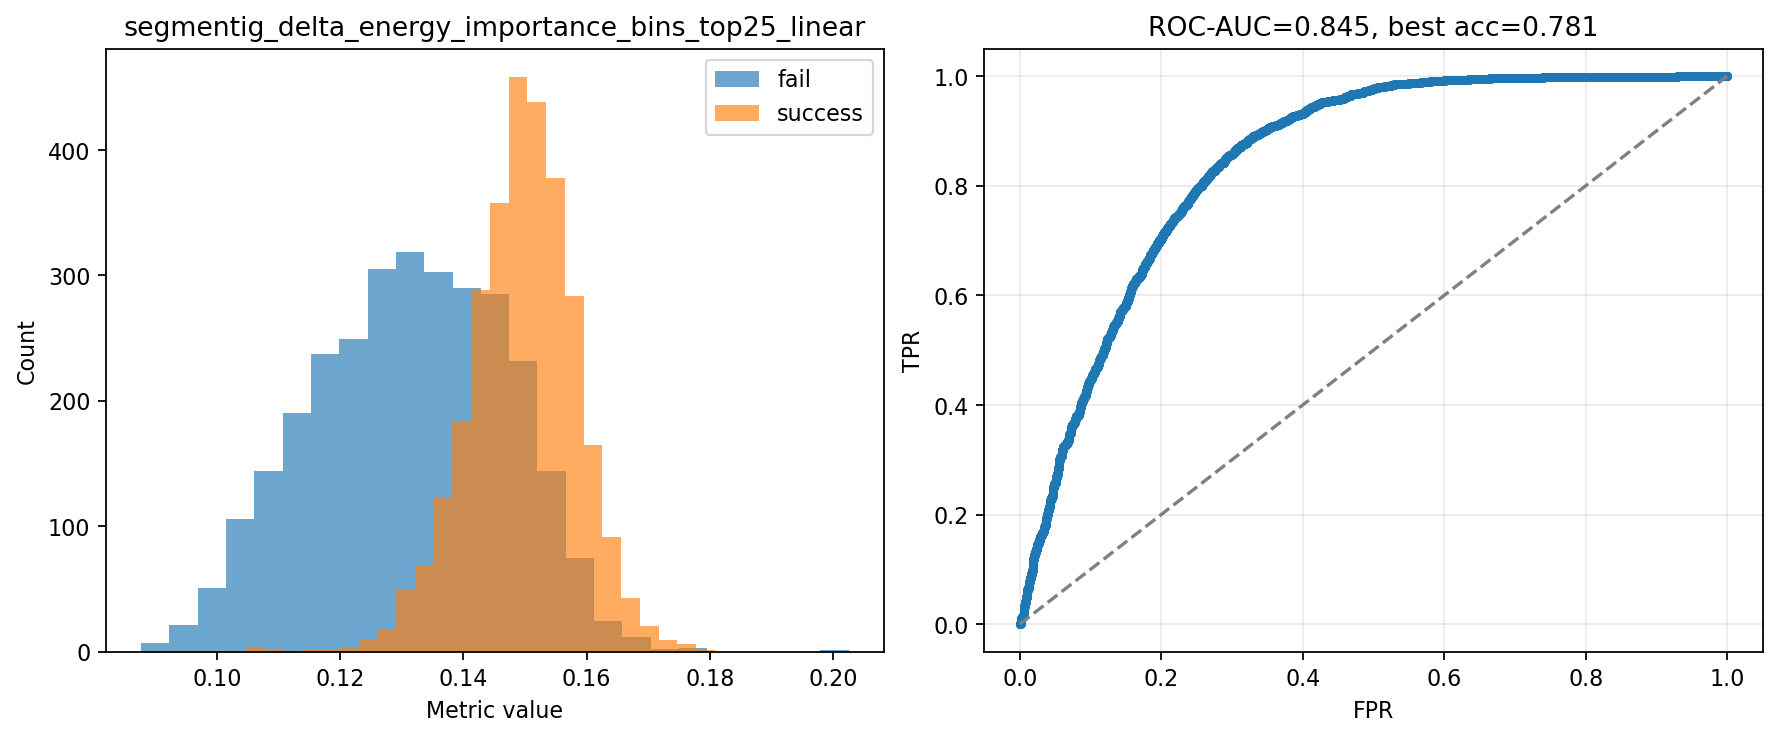

segmentig_delta_energy_importance_bins_top50_linear | roc_auc=0.843 | best_acc=0.779


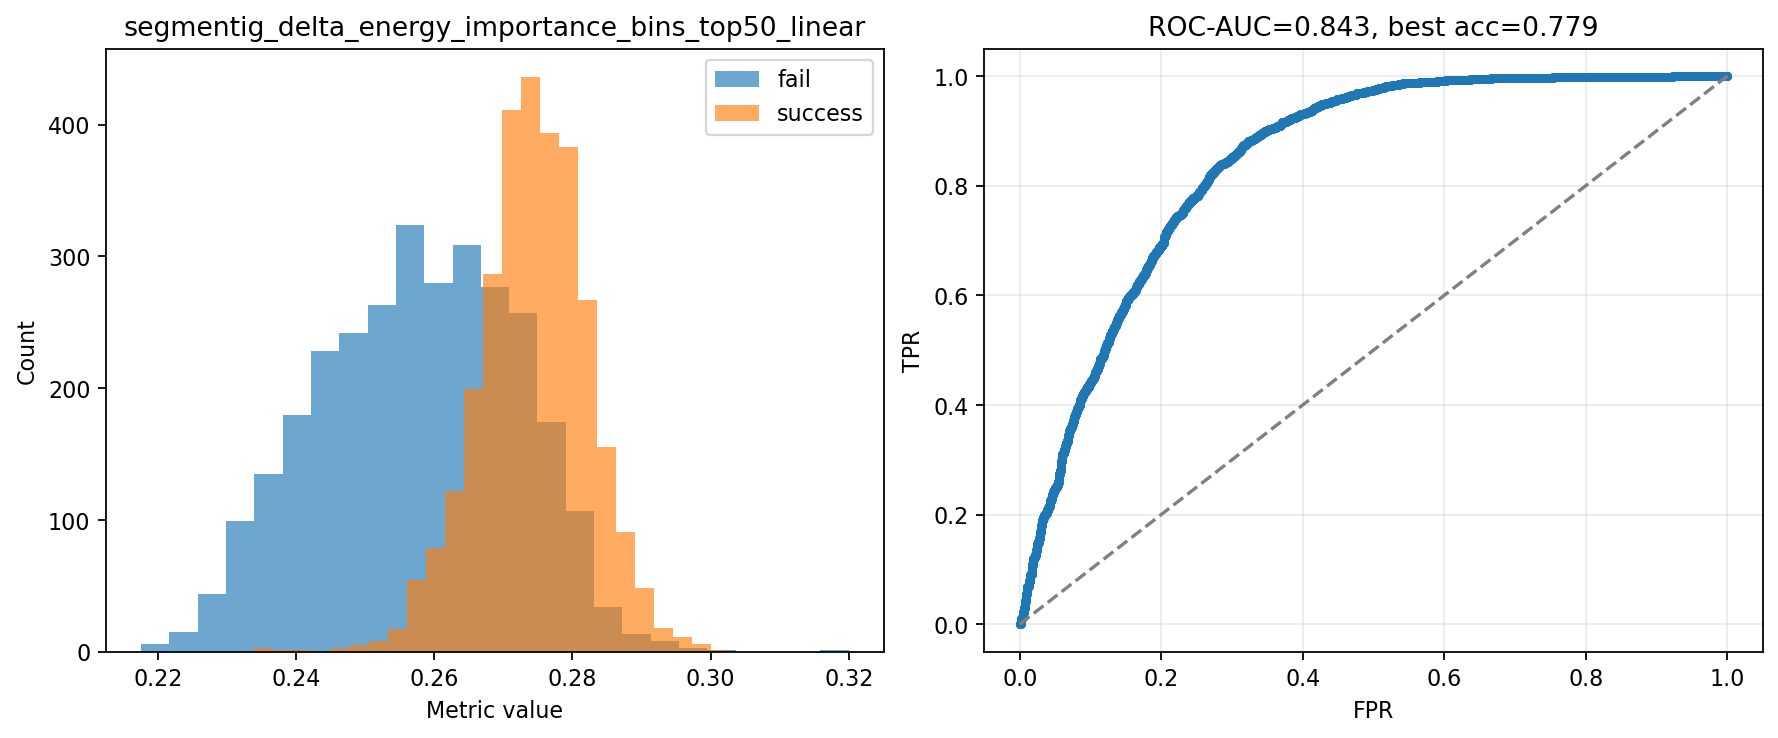

segmentig_delta_importance_product_unsigned | roc_auc=0.658 | best_acc=0.626


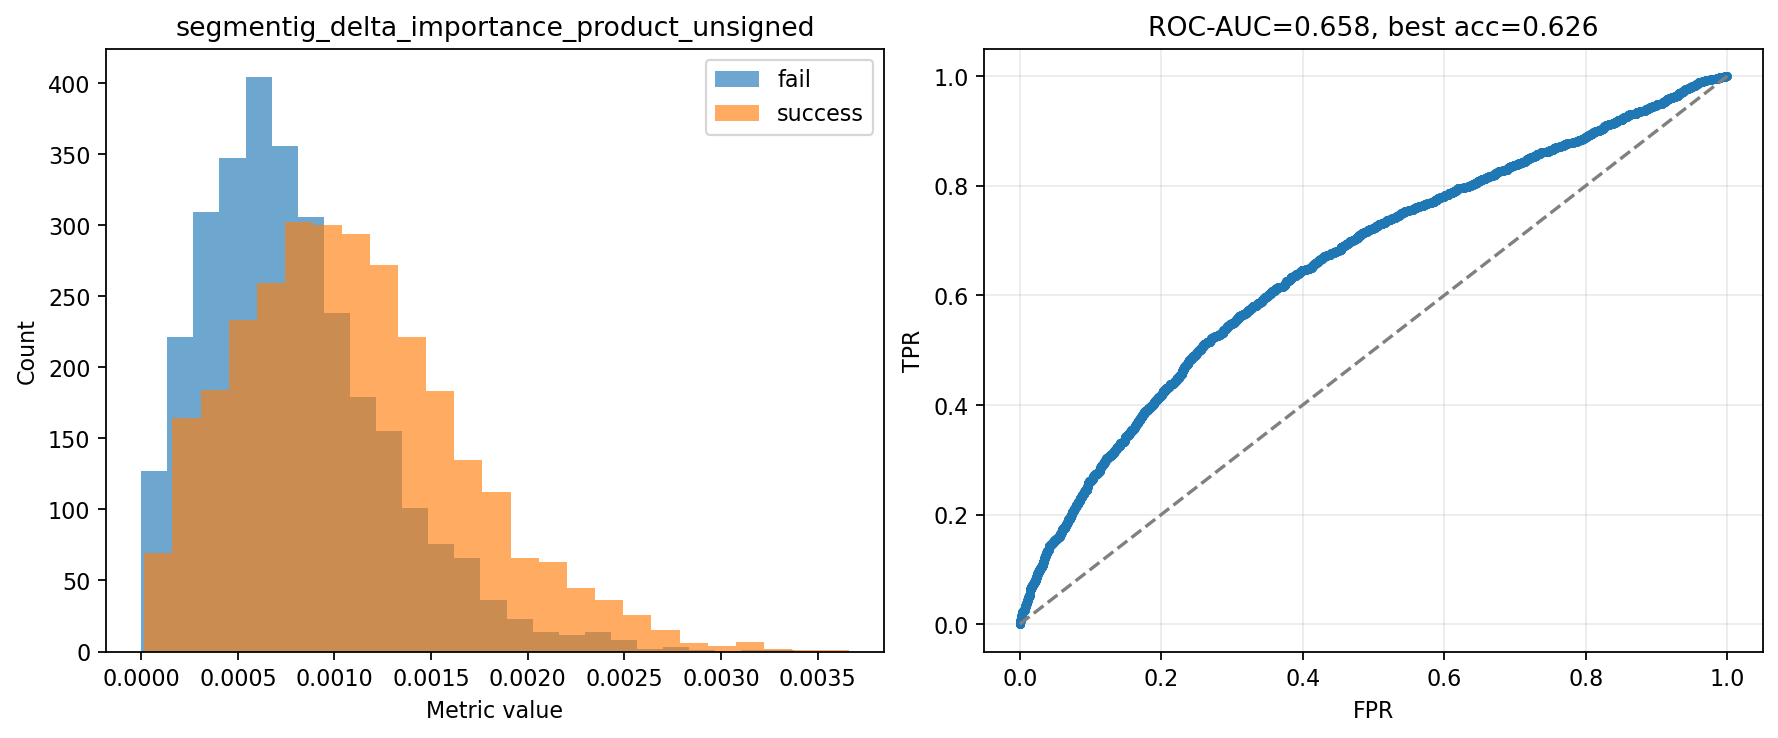

segmentig_delta_importance_product_signed | roc_auc=0.608 | best_acc=0.594


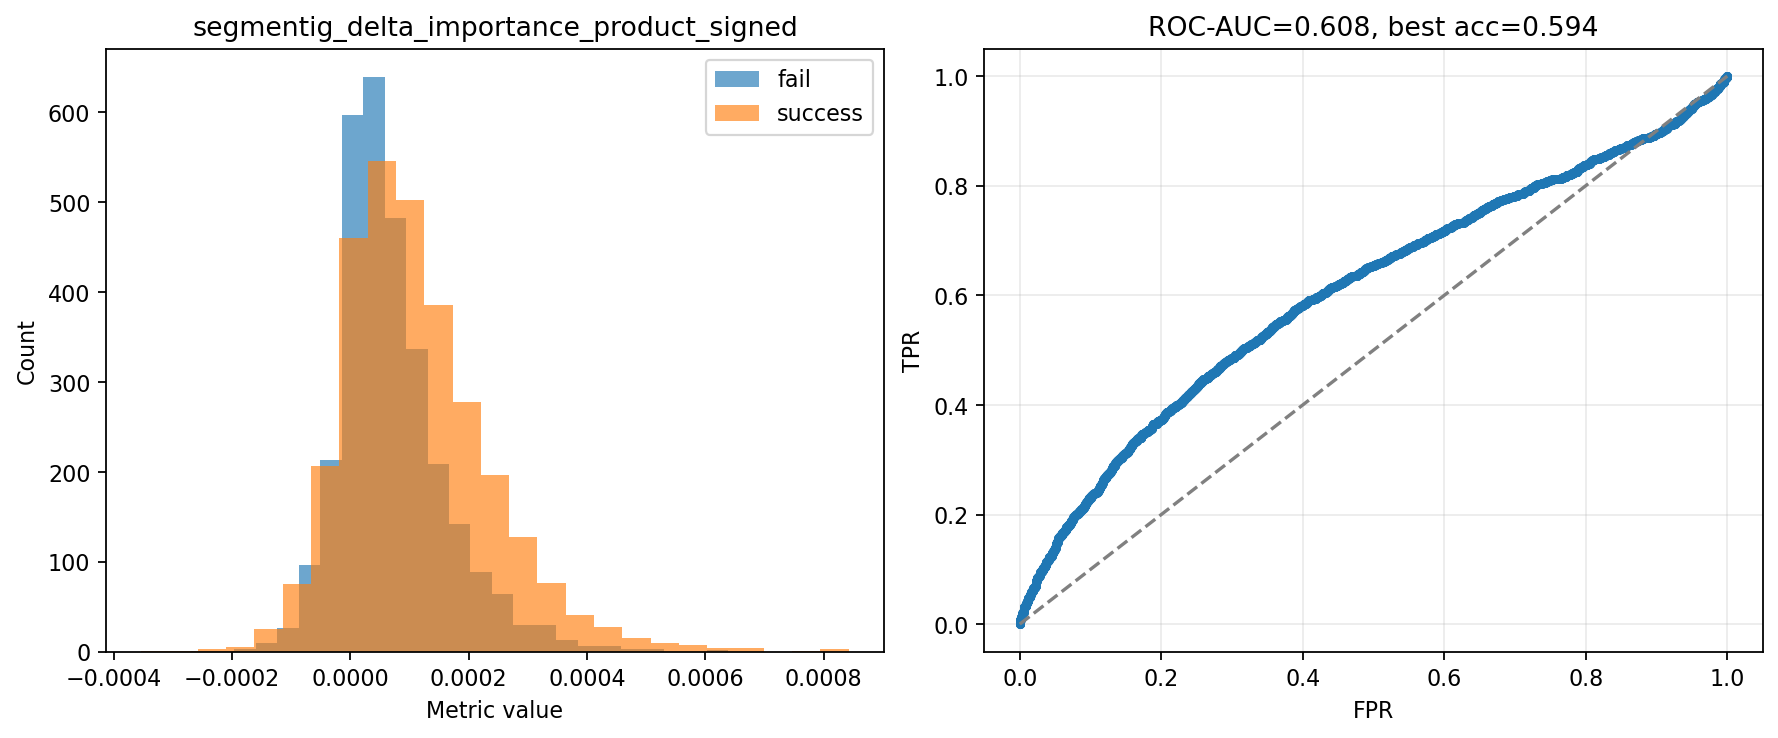

In [5]:
# SegmentIG0.1-only comparison: baseline + soft variants
rows_df = pd.DataFrame(sf['rows'])
quality_df = pd.DataFrame(sf['quality']).sort_values(['best_accuracy', 'roc_auc'], ascending=False)

baseline_metric = 'segmentig_delta_energy_in_importance_top'
product_metrics = [
    'segmentig_delta_importance_product_signed',
    'segmentig_delta_importance_product_unsigned',
]
cutoffs = [100, 50, 25, 10]
families = ['linear', 'reciprocal', 'exp']
binned_metrics = [
    f'segmentig_delta_energy_importance_bins_top{cutoff}_{family}'
    for cutoff in cutoffs
    for family in families
]
soft_metrics = [baseline_metric] + product_metrics + binned_metrics

known_quality = set(quality_df['metric'])
missing = [m for m in soft_metrics if m not in rows_df.columns or m not in known_quality]
if missing:
    raise RuntimeError(
        f'Нет soft-метрик {missing}. Перезапусти ячейку с '
        'run_segmentig_success_failure_metrics(), чтобы пересчитать sf.'
    )

def metric_family(metric):
    if metric == baseline_metric:
        return 'baseline_top5_binary'
    if metric.endswith('_signed'):
        return 'product_signed'
    if metric.endswith('_unsigned'):
        return 'product_unsigned'
    return metric.rsplit('_', 1)[-1] 

def metric_cutoff(metric):
    if '_bins_top' not in metric:
        return pd.NA
    return int(metric.split('_bins_top', 1)[1].split('_', 1)[0])

soft_quality = quality_df[quality_df['metric'].isin(soft_metrics)].copy()
soft_quality['family'] = soft_quality['metric'].map(metric_family)
soft_quality['cutoff_percent'] = soft_quality['metric'].map(metric_cutoff)
soft_quality = soft_quality.sort_values(['best_accuracy', 'roc_auc'], ascending=False)
display(soft_quality[['metric', 'family', 'cutoff_percent', 'roc_auc', 'best_accuracy', 'best_threshold', 'best_direction']])

success_means = rows_df.groupby('success')[soft_metrics].mean(numeric_only=True).T
success_means = success_means.rename(columns={False: 'fail_mean', True: 'success_mean'})
for col in ['fail_mean', 'success_mean']:
    if col not in success_means.columns:
        success_means[col] = float('nan')
success_means = success_means.reset_index(names='metric')
success_means['family'] = success_means['metric'].map(metric_family)
success_means['cutoff_percent'] = success_means['metric'].map(metric_cutoff)
display(success_means[['metric', 'family', 'cutoff_percent', 'fail_mean', 'success_mean']])

for _, row in soft_quality.iterrows():
    print(f"{row['metric']} | roc_auc={row['roc_auc']:.3f} | best_acc={row['best_accuracy']:.3f}")
    display(Image(filename=row['figure_path']))


## Logistic regression по 1%-бинам

Обучаем регуляризованную логистическую регрессию на 100 признаках: каждый признак — доля `|Δ|` в 1%-бине, где нейроны отсортированы по `|SegmentIG[0;0.1]|`. ElasticNet-CV подбирает силу регуляризации и смесь L1/L2; коэффициенты показывают, какие ранговые зоны важности модель считает полезными для разделения success/fail.


n_examples=6000, n_features=100
best_cv_auc=0.911, in_sample_auc=0.916
best_C=100, best_l1_ratio=1.00, intercept=-14.21
nonzero_coefficients=78/100


,bin,rank_percent_from,rank_percent_to,coef,abs_coef,nonzero
82,83,82,83,410.056334,410.056334,True
60,61,60,61,260.569177,260.569177,True
0,1,0,1,176.032933,176.032933,True
55,56,55,56,165.433475,165.433475,True
46,47,46,47,143.043977,143.043977,True
41,42,41,42,135.688155,135.688155,True
4,5,4,5,132.806999,132.806999,True
79,80,79,80,130.544982,130.544982,True
42,43,42,43,120.763864,120.763864,True
2,3,2,3,114.673081,114.673081,True


,bin,rank_percent_from,rank_percent_to,coef,abs_coef,nonzero
33,34,33,34,-263.010545,263.010545,True
98,99,98,99,-254.394601,254.394601,True
62,63,62,63,-231.113827,231.113827,True
40,41,40,41,-162.562276,162.562276,True
26,27,26,27,-156.959018,156.959018,True
10,11,10,11,-122.404975,122.404975,True
85,86,85,86,-105.644178,105.644178,True
80,81,80,81,-103.180242,103.180242,True
97,98,97,98,-102.313889,102.313889,True
27,28,27,28,-97.166369,97.166369,True


,bin,rank_percent_from,rank_percent_to,coef,abs_coef,nonzero
0,1,0,1,176.032933,176.032933,True
1,2,1,2,32.447290,32.447290,True
2,3,2,3,114.673081,114.673081,True
3,4,3,4,57.285793,57.285793,True
4,5,4,5,132.806999,132.806999,True
...,...,...,...,...,...,...
95,96,95,96,18.686127,18.686127,True
96,97,96,97,-31.488283,31.488283,True
97,98,97,98,-102.313889,102.313889,True
98,99,98,99,-254.394601,254.394601,True


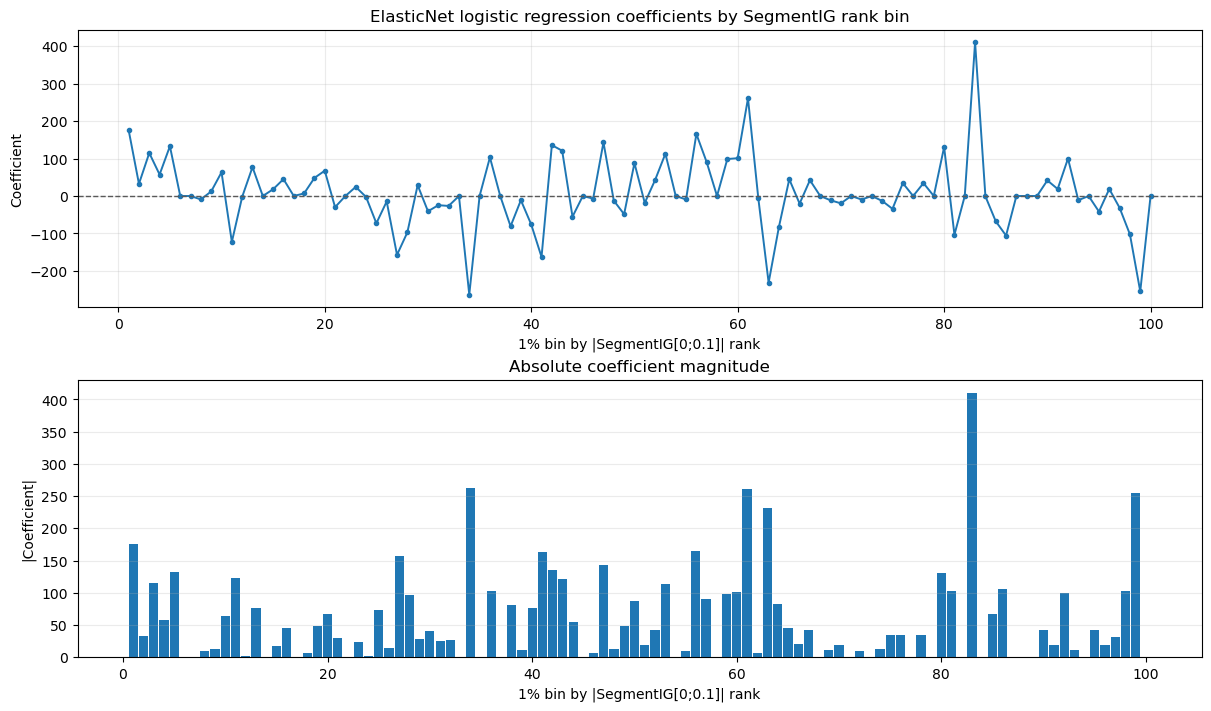

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold

feature_cols = [f'segmentig_delta_energy_importance_binfrac_{idx:03d}' for idx in range(1, 101)]
missing = [col for col in feature_cols if col not in rows_df.columns]
if missing:
    raise RuntimeError(
        f'Нет bin-fraction признаков: {missing[:5]}... Перезапусти ячейку '
        'run_segmentig_success_failure_metrics(), чтобы sf был пересчитан новым кодом.'
    )

X_df = rows_df[feature_cols].astype('float64')
y = rows_df['success'].astype(int).to_numpy()
finite_mask = np.isfinite(X_df.to_numpy()).all(axis=1)
X = X_df.loc[finite_mask].to_numpy()
y_fit = y[finite_mask]
if len(np.unique(y_fit)) != 2:
    raise RuntimeError('Для обучения нужны оба класса success/fail.')

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=17)
logreg = LogisticRegressionCV(
    Cs=np.logspace(-4, 2, 20),
    penalty='elasticnet',
    solver='saga',
    scoring='roc_auc',
    class_weight='balanced',
    l1_ratios=[0.0, 0.25, 0.5, 0.75, 1.0],
    cv=cv,
    max_iter=20000,
    n_jobs=-1,
    refit=True,
    random_state=17,
)
logreg.fit(X, y_fit)

score_key = sorted(logreg.scores_.keys())[-1]
cv_scores = logreg.scores_[score_key]
cv_mean = cv_scores.mean(axis=0)
best_cv_auc = float(np.nanmax(cv_mean))
train_score = logreg.decision_function(X)
train_auc = float(roc_auc_score(y_fit, train_score))
coef = logreg.coef_[0]
intercept = float(logreg.intercept_[0])
learned_score_col = "segmentig_logreg_bin_score"
rows_df.loc[finite_mask, learned_score_col] = train_score

coef_df = pd.DataFrame({
    'bin': np.arange(1, 101),
    'rank_percent_from': np.arange(0, 100),
    'rank_percent_to': np.arange(1, 101),
    'coef': coef,
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df['nonzero'] = coef_df['coef'].abs() > 1e-10

print(f"n_examples={len(y_fit)}, n_features={X.shape[1]}")
print(f"best_cv_auc={best_cv_auc:.3f}, in_sample_auc={train_auc:.3f}")
print(f"best_C={float(logreg.C_[0]):.4g}, best_l1_ratio={float(logreg.l1_ratio_[0]):.2f}, intercept={intercept:.4g}")
print(f"nonzero_coefficients={int(coef_df['nonzero'].sum())}/100")

display(coef_df.sort_values('coef', ascending=False).head(15))
display(coef_df.sort_values('coef', ascending=True).head(15))
display(coef_df)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
axes[0].plot(coef_df['bin'], coef_df['coef'], marker='o', linewidth=1.4, markersize=3)
axes[0].axhline(0, color='0.35', linestyle='--', linewidth=1)
axes[0].set_title('ElasticNet logistic regression coefficients by SegmentIG rank bin')
axes[0].set_xlabel('1% bin by |SegmentIG[0;0.1]| rank')
axes[0].set_ylabel('Coefficient')
axes[0].grid(alpha=0.25)
axes[1].bar(coef_df['bin'], coef_df['abs_coef'], width=0.9)
axes[1].set_title('Absolute coefficient magnitude')
axes[1].set_xlabel('1% bin by |SegmentIG[0;0.1]| rank')
axes[1].set_ylabel('|Coefficient|')
axes[1].grid(axis='y', alpha=0.25)
plt.show()


### Проверка: меньше бинов и более мелкие 0.1%-бины

Тут проверяем две вещи. Во-первых, что будет, если для 1%-бинов брать только первые 5 или 10 бинов, а не все 100. Во-вторых, пробуем более мелкую нарезку по 0.1% и смотрим окна `1%`, `5%`, `10%`. Если обученные веса реально помогают, это должно быть видно на validation, а не только на train.


,variant,model_kind,n_features,C,train_acc,train_auc,val_acc,val_auc,all_best_acc,all_auc
24,0.1% bins: top 10% / L2 C=0.001,fixed_l2,100,0.001000,0.830,0.8773,0.790,0.8519,0.800833,0.866361
23,0.1% bins: top 10% / L2 C=0.003,fixed_l2,100,0.003000,0.855,0.8912,0.785,0.8622,0.808333,0.874450
15,0.1% bins: top 5% / L2 CV,cv_l2,50,0.056234,0.830,0.8939,0.785,0.8385,0.780000,0.845631
20,0.1% bins: top 10% / L2 CV,cv_l2,100,0.010000,0.870,0.9181,0.775,0.8729,0.816833,0.884620
22,0.1% bins: top 10% / L2 C=0.01,fixed_l2,100,0.010000,0.870,0.9181,0.775,0.8729,0.816833,0.884623
21,0.1% bins: top 10% / L2 C=0.03,fixed_l2,100,0.030000,0.895,0.9440,0.775,0.8720,0.817833,0.888059
16,0.1% bins: top 5% / L2 C=0.03,fixed_l2,50,0.030000,0.820,0.8813,0.775,0.8422,0.782333,0.847661
6,1% bins: top 10% / L2 C=0.03,fixed_l2,10,0.030000,0.820,0.8685,0.770,0.8297,0.789333,0.856139
17,0.1% bins: top 5% / L2 C=0.01,fixed_l2,50,0.010000,0.805,0.8644,0.765,0.8431,0.783333,0.848183
7,1% bins: top 10% / L2 C=0.01,fixed_l2,10,0.010000,0.815,0.8633,0.765,0.8274,0.787833,0.854732


,method,source,weights,train_acc,val_acc,val_auc
0,ML: 0.1% bins: top 10% / L2 C=0.001,ML,learned,0.830,0.790,0.8519
1,ML: 0.1% bins: top 10% / L2 C=0.003,ML,learned,0.855,0.785,0.8622
2,segmentig_hand_spatial_top10_jaccard,precomputed,,0.785,0.785,0.8448
3,ML: 0.1% bins: top 5% / L2 CV,ML,learned,0.830,0.785,0.8385
4,0.1% top10 sqrt_reciprocal,manual_0.1%,"[1, 1/sqrt(2), ..., 1/sqrt(100)]",0.780,0.780,0.8495
5,segmentig_delta_energy_importance_bins_top25_r...,precomputed,,0.785,0.780,0.8485
6,segmentig_delta_energy_importance_bins_top50_r...,precomputed,,0.785,0.780,0.8484
7,ML: 0.1% bins: top 10% / L2 CV,ML,learned,0.870,0.775,0.8729
8,ML: 0.1% bins: top 10% / L2 C=0.01,ML,learned,0.870,0.775,0.8729
9,ML: 0.1% bins: top 10% / L2 C=0.03,ML,learned,0.895,0.775,0.8720


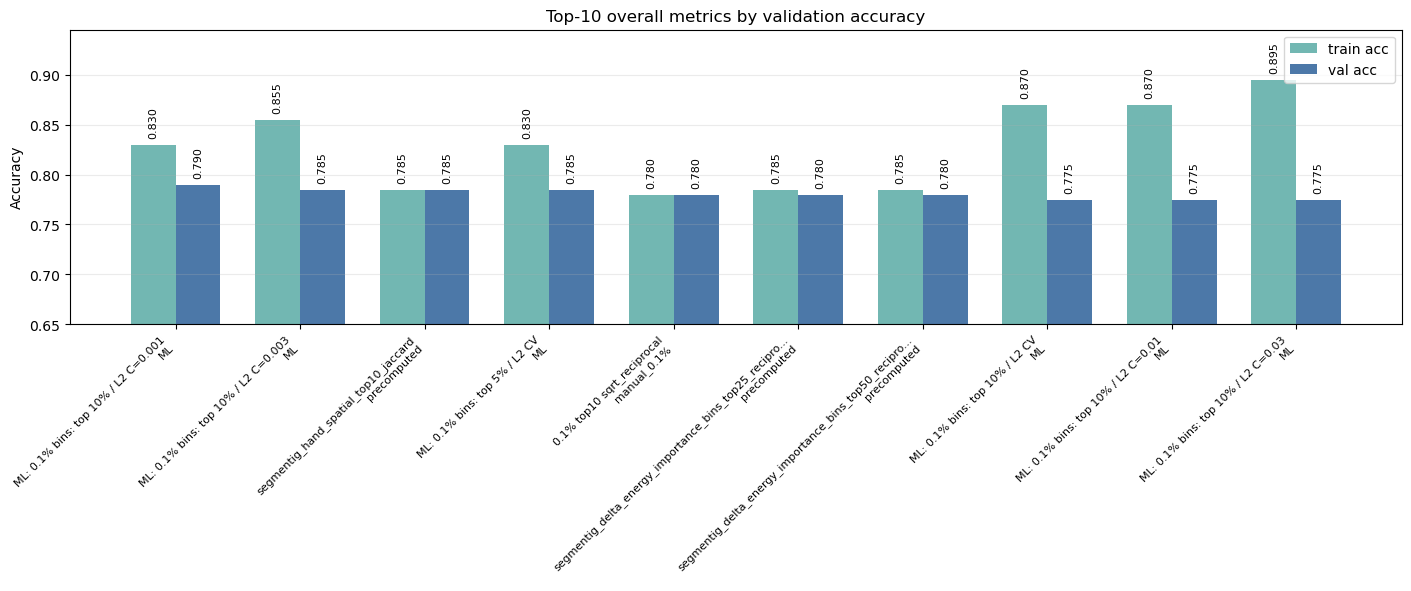

,method,weights,train_acc,val_acc,val_auc,kind
0,best ML\n0.1% bins: top 10%\nL2 C=0.001,learned,0.830,0.790,0.8519,learned
1,0.1% top10 sqrt_reciprocal,"[1, 1/sqrt(2), ..., 1/sqrt(100)]",0.780,0.780,0.8495,manual_0.1%
2,top10% flat,"[1, 1, ..., 1]",0.780,0.775,0.8416,manual
3,0.1% top10 flat,"[1, 1, ..., 1]",0.780,0.775,0.8416,manual_0.1%
4,0.1% top5 sqrt_reciprocal,"[1, 1/sqrt(2), ..., 1/sqrt(50)]",0.785,0.765,0.8494,manual_0.1%
5,0.1% top10 linear,"[1, 0.99, ..., 0.01]",0.795,0.765,0.8444,manual_0.1%
6,0.1% top5 linear,"[1, 0.98, ..., 0.02]",0.775,0.760,0.8477,manual_0.1%
7,0.1% top10 exp,"[1, 0.966, ..., 0.0324]",0.780,0.760,0.8474,manual_0.1%
8,top10% reciprocal,"[1, 1/2, ..., 1/10]",0.780,0.760,0.8473,manual
9,top5% flat,"[1, 1, ..., 1]",0.795,0.760,0.8447,manual


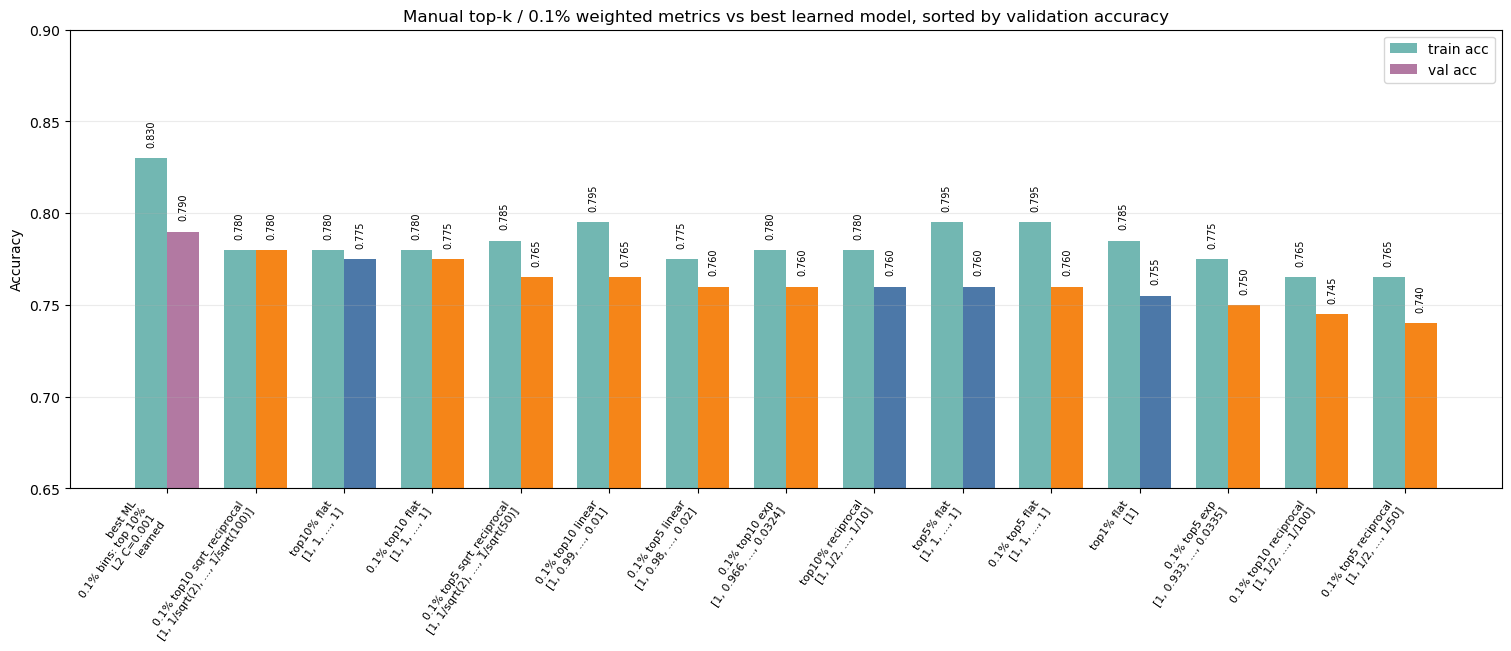

,method,cutoff_percent,weight_family,n_bins,weights,train_acc,val_acc,val_auc
0,0.1% top10 sqrt_reciprocal,10,sqrt_reciprocal,100,"[1, 1/sqrt(2), ..., 1/sqrt(100)]",0.780,0.780,0.8495
1,0.1% top10 flat,10,flat,100,"[1, 1, ..., 1]",0.780,0.775,0.8416
2,0.1% top5 sqrt_reciprocal,5,sqrt_reciprocal,50,"[1, 1/sqrt(2), ..., 1/sqrt(50)]",0.785,0.765,0.8494
3,0.1% top10 linear,10,linear,100,"[1, 0.99, ..., 0.01]",0.795,0.765,0.8444
4,0.1% top5 linear,5,linear,50,"[1, 0.98, ..., 0.02]",0.775,0.760,0.8477
5,0.1% top10 exp,10,exp,100,"[1, 0.966, ..., 0.0324]",0.780,0.760,0.8474
6,0.1% top5 flat,5,flat,50,"[1, 1, ..., 1]",0.795,0.760,0.8447
7,0.1% top5 exp,5,exp,50,"[1, 0.933, ..., 0.0335]",0.775,0.750,0.8427
8,0.1% top10 reciprocal,10,reciprocal,100,"[1, 1/2, ..., 1/100]",0.765,0.745,0.8324
9,0.1% top5 reciprocal,5,reciprocal,50,"[1, 1/2, ..., 1/50]",0.765,0.740,0.8304


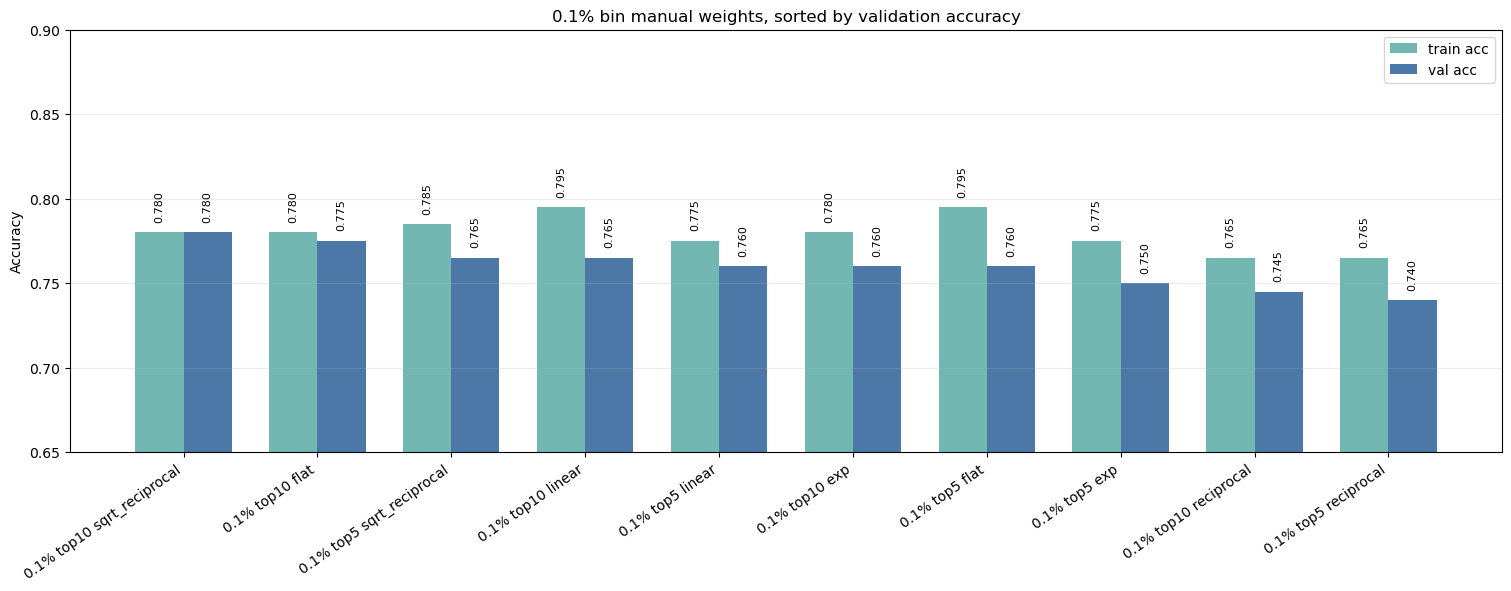

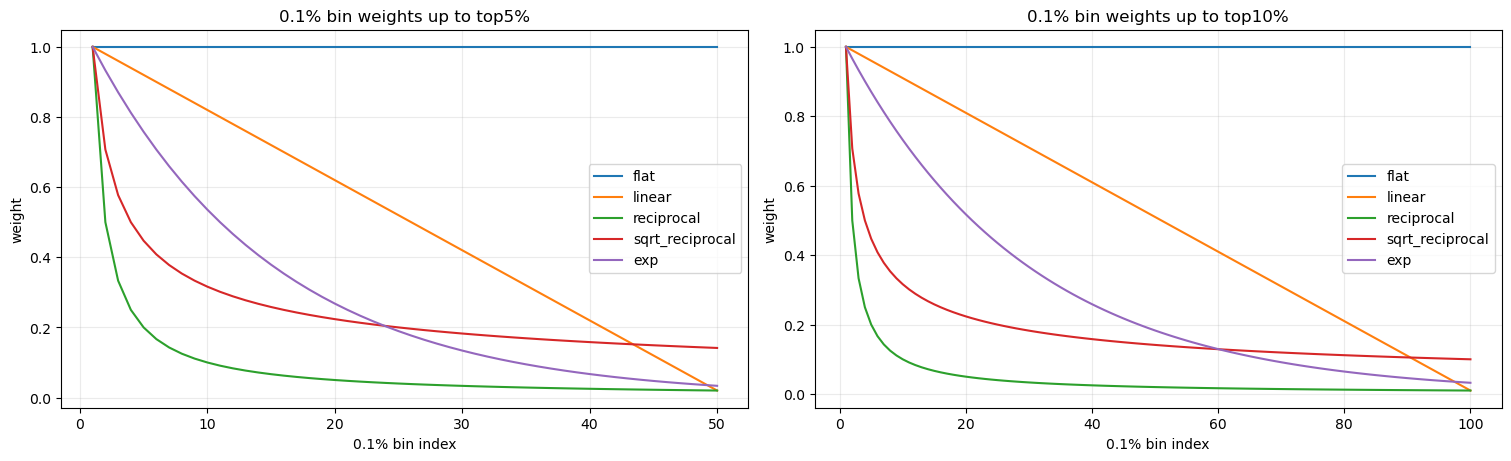

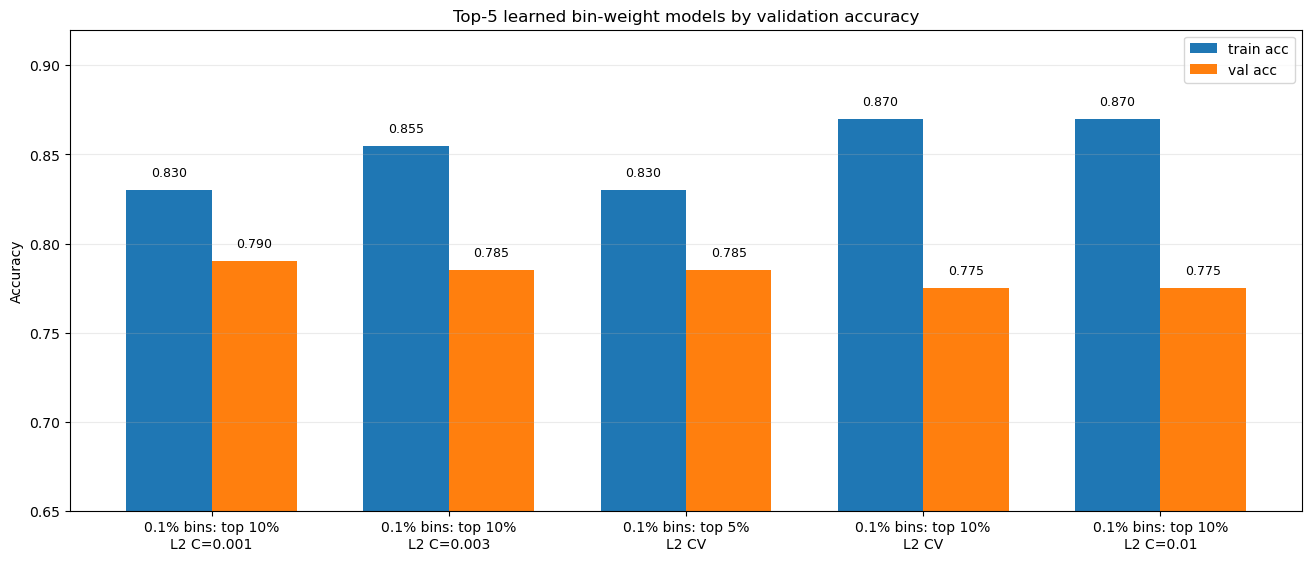

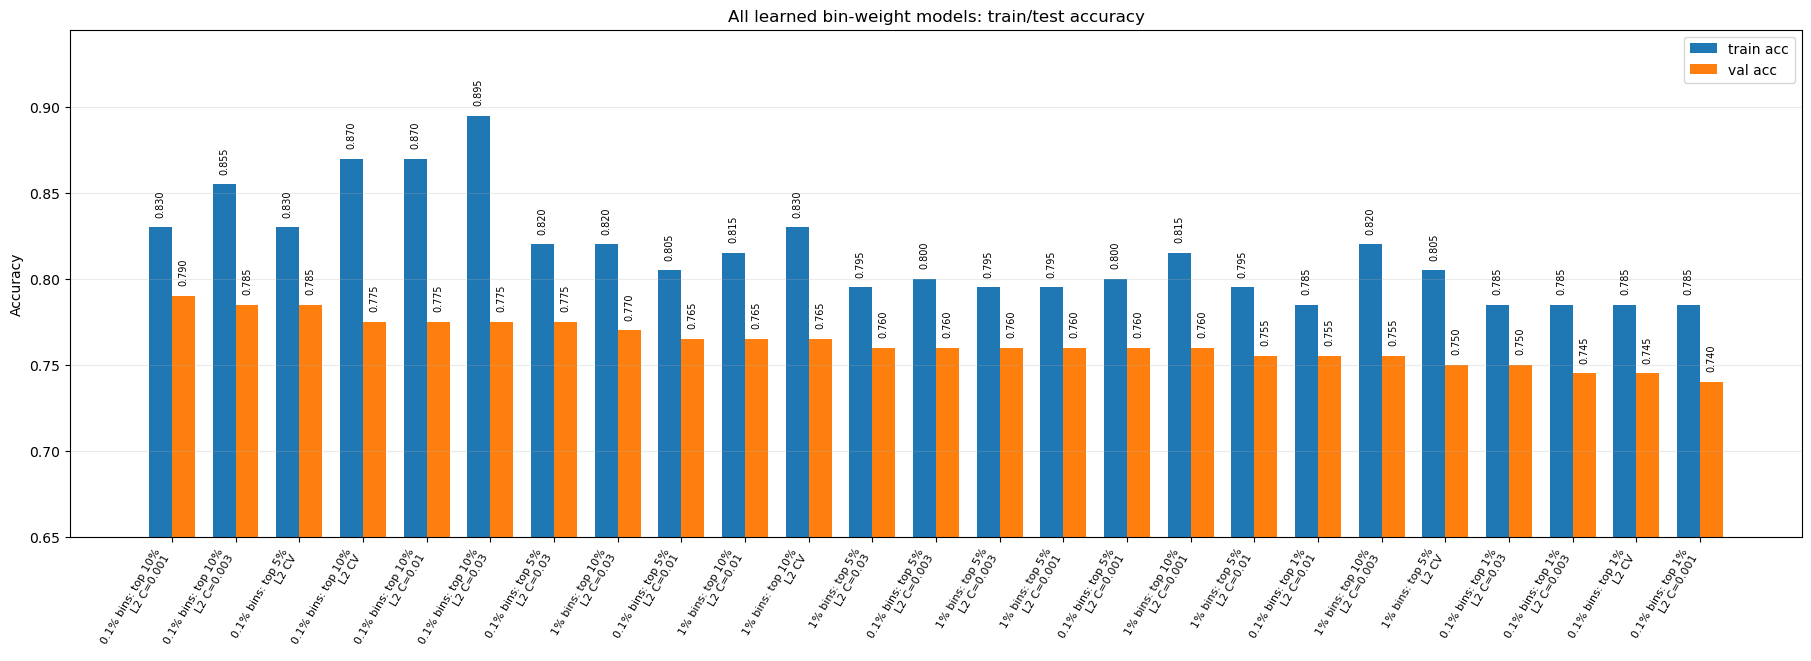

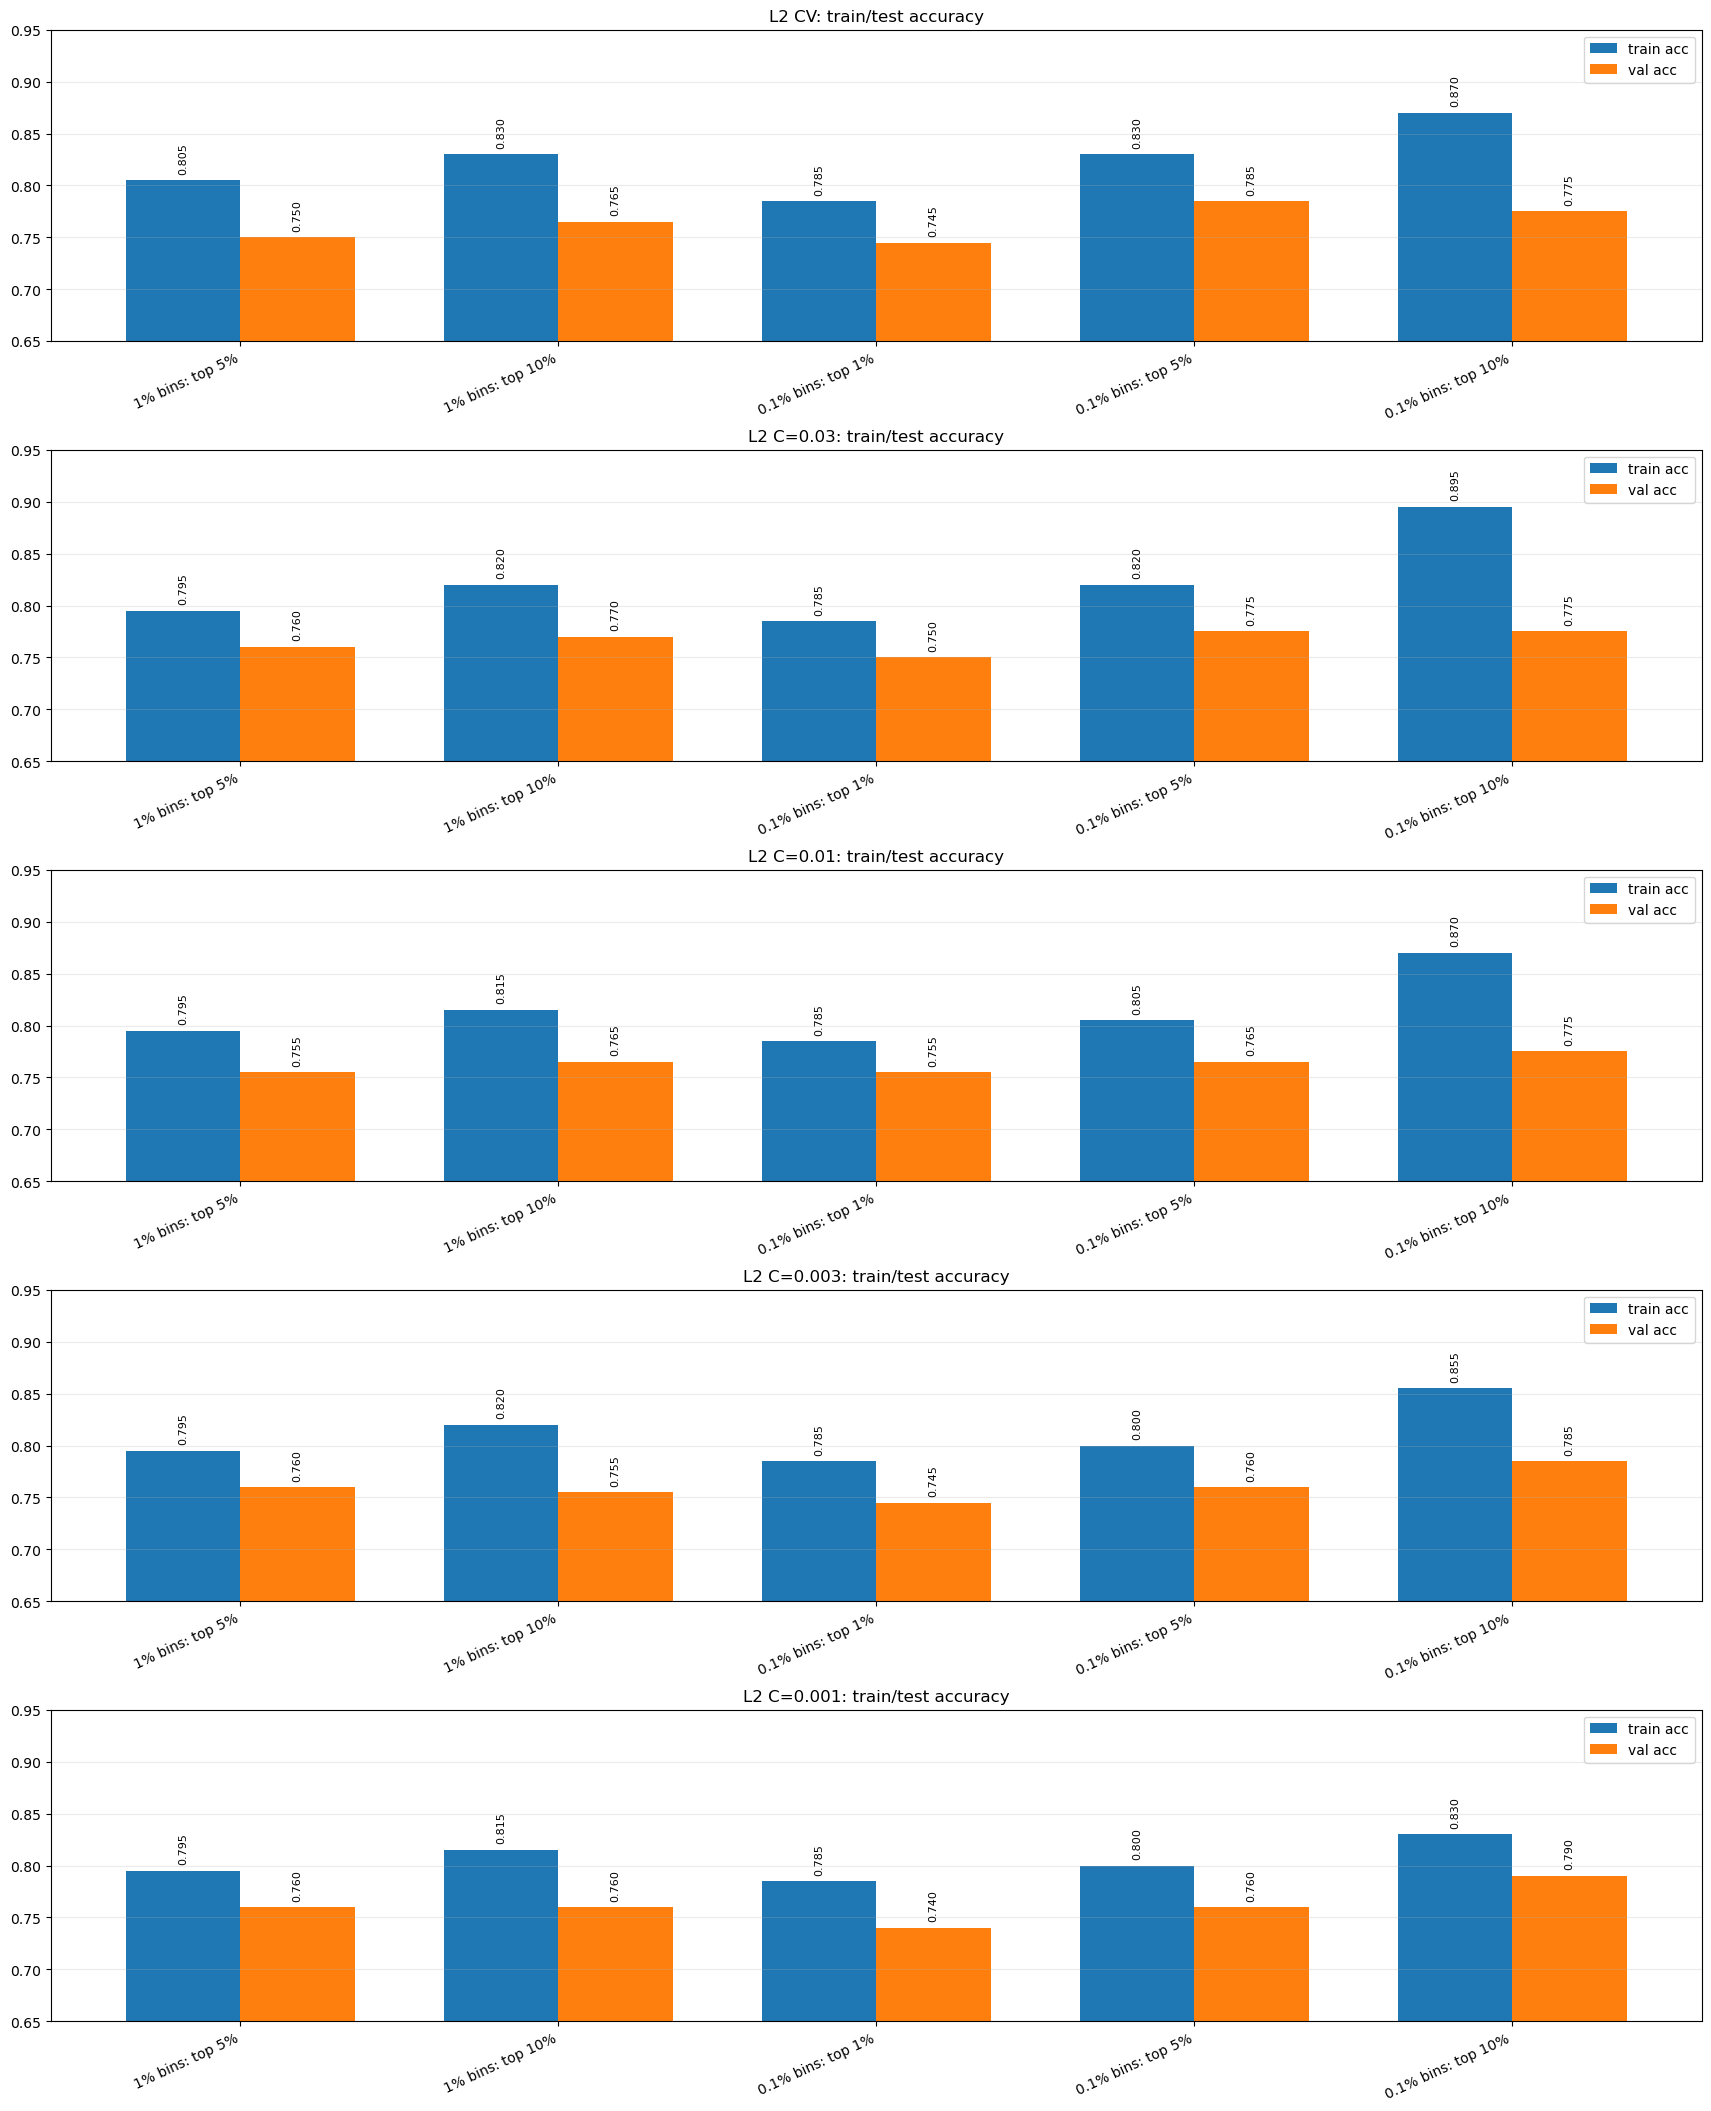

,regularization,variant,n_features,C,train_acc,val_acc,train_auc,val_auc
0,L2 C=0.001,0.1% bins: top 10% / L2 C=0.001,100,0.001000,0.830,0.790,0.8773,0.8519
1,L2 C=0.003,0.1% bins: top 10% / L2 C=0.003,100,0.003000,0.855,0.785,0.8912,0.8622
2,L2 C=0.01,0.1% bins: top 10% / L2 C=0.01,100,0.010000,0.870,0.775,0.9181,0.8729
3,L2 C=0.03,0.1% bins: top 10% / L2 C=0.03,100,0.030000,0.895,0.775,0.9440,0.8720
4,L2 CV,0.1% bins: top 5% / L2 CV,50,0.056234,0.830,0.785,0.8939,0.8385


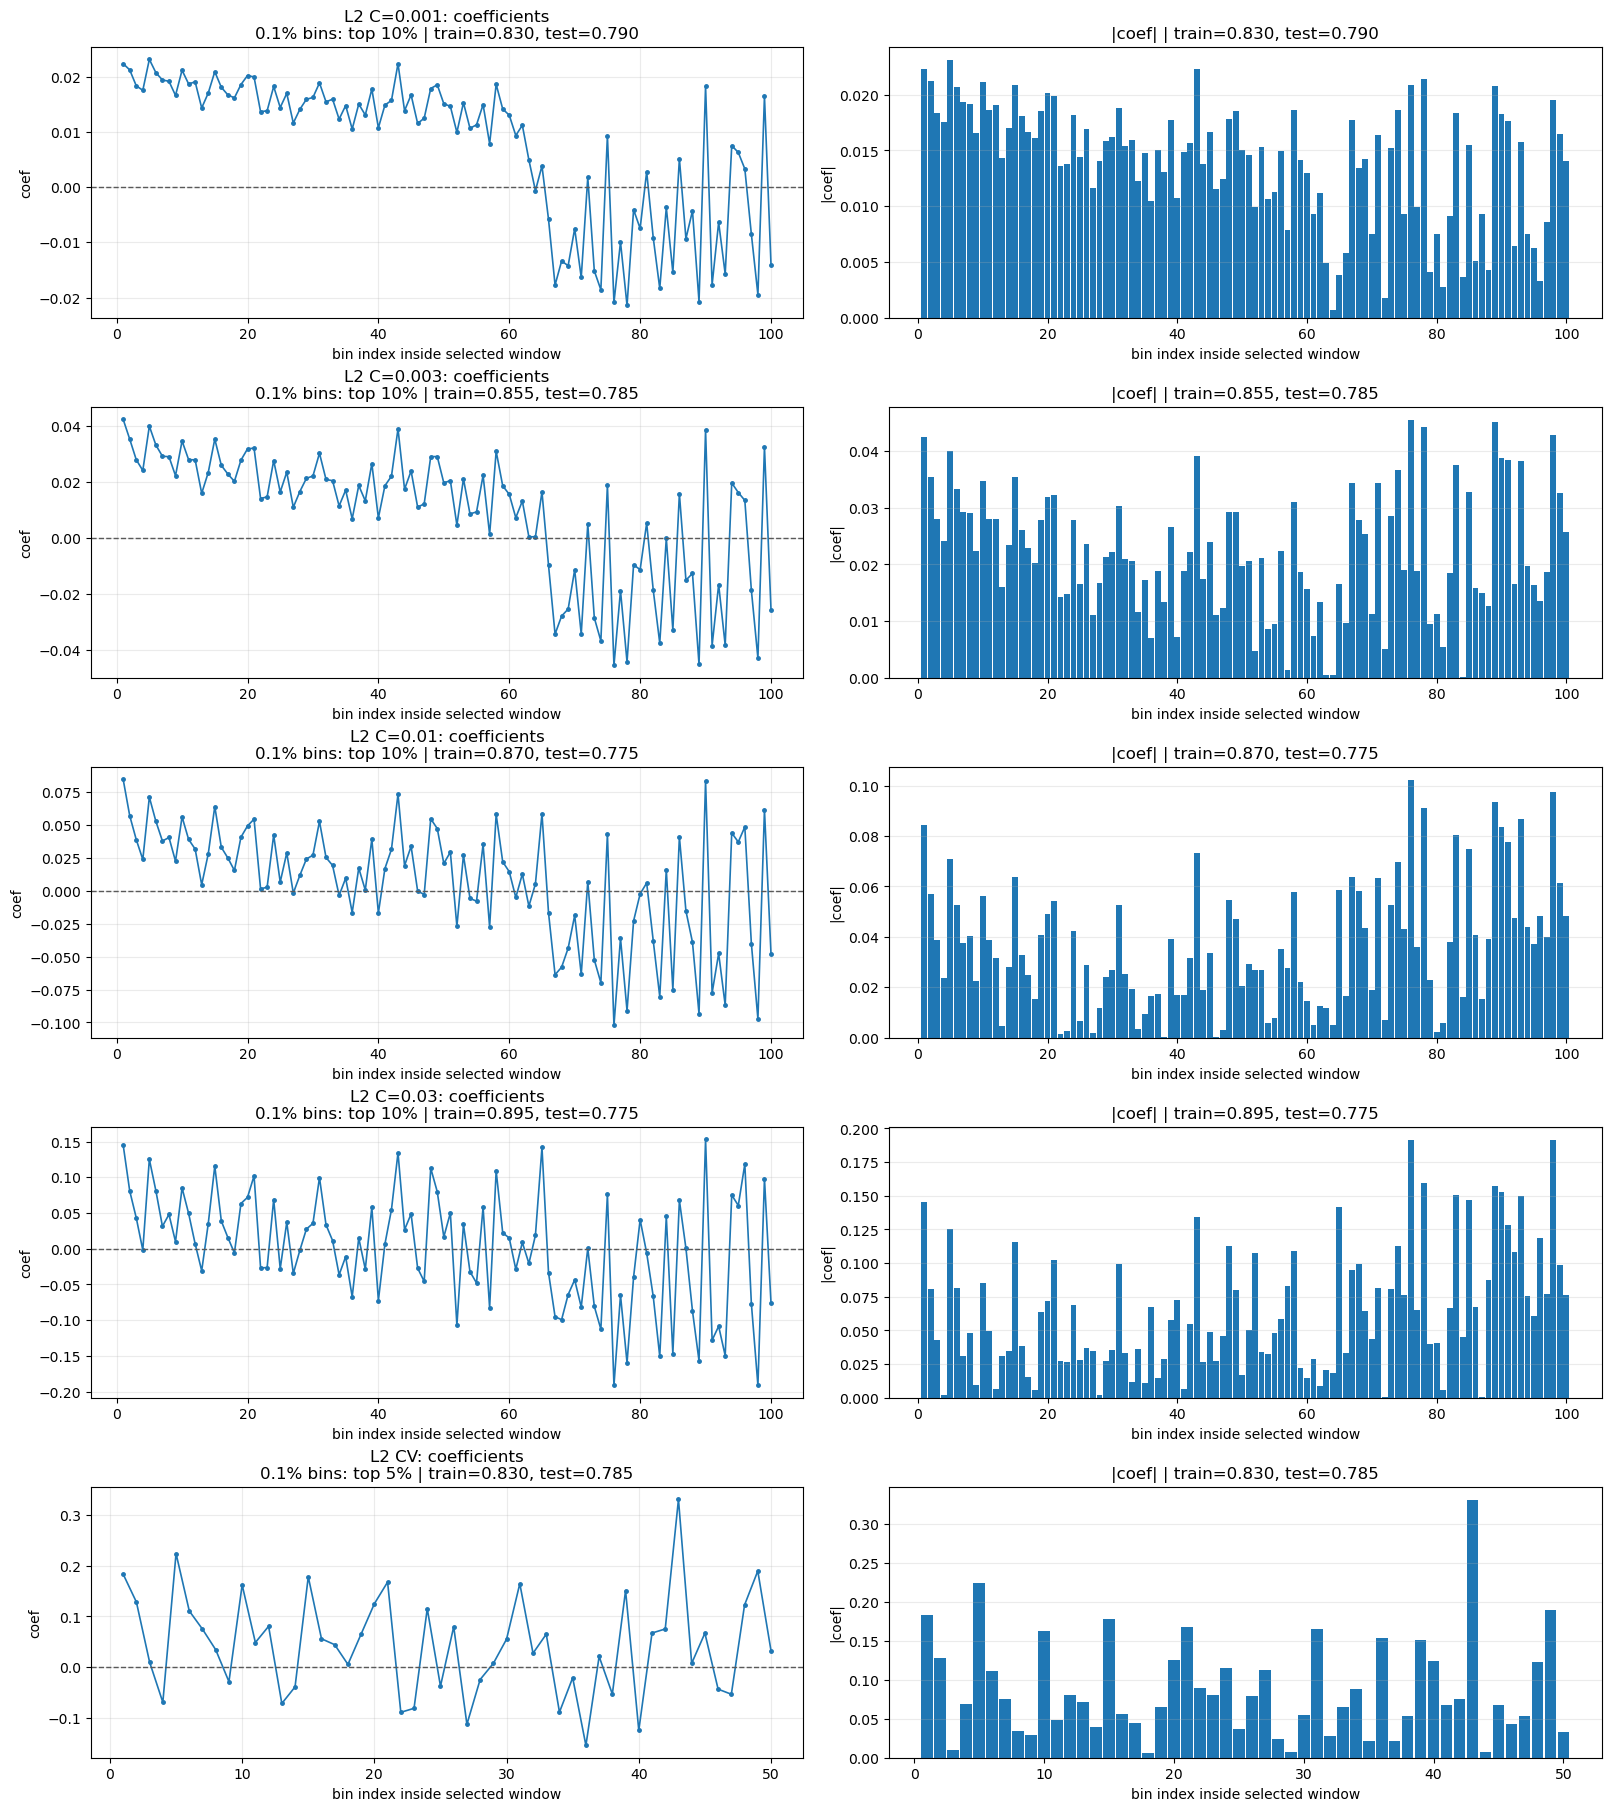

,feature_idx,coef,abs_coef
4,5,0.023111,0.023111
0,1,0.022336,0.022336
42,43,0.022329,0.022329
77,78,-0.021423,0.021423
1,2,0.021205,0.021205
9,10,0.021150,0.021150
75,76,-0.020888,0.020888
14,15,0.020871,0.020871
88,89,-0.020738,0.020738
5,6,0.020698,0.020698


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    from patch_success_analysis.metrics import best_accuracy, importance_rank_bin_energy_fractions
except ModuleNotFoundError:
    from new_experiments.patch_success_analysis.metrics import best_accuracy, importance_rank_bin_energy_fractions


def _resolve_layer_map_path(cache_path):
    path = Path(str(cache_path))
    if path.exists():
        return path
    alt = Path('new_experiments') / path
    if alt.exists():
        return alt
    raise FileNotFoundError(f'Layer map cache not found: {cache_path}')


selection_random_state = 31
rng = np.random.default_rng(selection_random_state)
y = rows_df['success'].astype(bool).to_numpy().astype(int)
success_idx = np.flatnonzero(y == 1)
fail_idx = np.flatnonzero(y == 0)
rng.shuffle(success_idx)
rng.shuffle(fail_idx)
if len(success_idx) < 200 or len(fail_idx) < 200:
    raise RuntimeError(f'Нужно 200 success и 200 fail для split 100/100 train + 100/100 val, got {len(success_idx)=}, {len(fail_idx)=}')
train_idx = np.concatenate([success_idx[:100], fail_idx[:100]])
val_idx = np.concatenate([success_idx[100:200], fail_idx[100:200]])
rng.shuffle(train_idx)
rng.shuffle(val_idx)


def _eval_scores(train_scores, train_y, eval_scores, eval_y):
    best = best_accuracy(train_y.astype(bool), train_scores)
    direction = int(best['direction'])
    threshold = float(best['threshold'])
    pred = eval_scores >= threshold if direction == 1 else eval_scores <= threshold
    return {
        'accuracy': float(accuracy_score(eval_y, pred)),
        'roc_auc': float(roc_auc_score(eval_y, eval_scores)),
        'direction': direction,
        'threshold': threshold,
        'train_best_accuracy': float(best['accuracy']),
    }


def _fit_logreg_variant(name, X, *, model_kind='cv_l2', fixed_c=0.03):
    X = np.asarray(X, dtype='float64')
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    if model_kind == 'fixed_l2':
        model = make_pipeline(StandardScaler(), LogisticRegression(
            C=float(fixed_c), penalty='l2', class_weight='balanced', max_iter=20000, solver='lbfgs',
        ))
    else:
        model = make_pipeline(StandardScaler(), LogisticRegressionCV(
            Cs=np.logspace(-5, 1, 25), cv=5, penalty='l2', scoring='roc_auc',
            class_weight='balanced', max_iter=20000, solver='lbfgs', refit=True,
        ))
    model.fit(X_train, y_train)
    train_scores = model.decision_function(X_train)
    val_scores = model.decision_function(X_val)
    all_scores = model.decision_function(X)
    train_eval = _eval_scores(train_scores, y_train, train_scores, y_train)
    val_eval = _eval_scores(train_scores, y_train, val_scores, y_val)
    all_best = best_accuracy(y.astype(bool), all_scores)
    lr = model.named_steps.get('logisticregressioncv') or model.named_steps.get('logisticregression')
    return {
        'variant': name,
        'model_kind': model_kind,
        'n_features': int(X.shape[1]),
        'C': float(lr.C_[0]) if hasattr(lr, 'C_') else float(lr.C),
        'train_acc': train_eval['accuracy'],
        'train_auc': float(roc_auc_score(y_train, train_scores)),
        'val_acc': val_eval['accuracy'],
        'val_auc': val_eval['roc_auc'],
        'all_best_acc': float(all_best['accuracy']),
        'all_auc': float(roc_auc_score(y, all_scores)),
        'coef': lr.coef_[0].copy(),
    }


# 1%-бины: берём первые 5 и первые 10 binfrac-признаков.
one_percent_cols = [f'segmentig_delta_energy_importance_binfrac_{idx:03d}' for idx in range(1, 101)]
missing = [col for col in one_percent_cols if col not in rows_df.columns]
if missing:
    raise RuntimeError(f'Нет 1%-bin features: {missing[:5]}')
X_1pct_5 = rows_df[one_percent_cols[:5]].astype('float64').to_numpy()
X_1pct_10 = rows_df[one_percent_cols[:10]].astype('float64').to_numpy()

# 0.1%-бины: считаем из сохранённых layer maps, без нового SegmentIG.
def _load_01pct_features(row):
    cache_path = row.get('layer_maps_cache_path')
    if not isinstance(cache_path, str) or not cache_path:
        raise RuntimeError('В rows_df нет layer_maps_cache_path, нельзя быстро посчитать 0.1%-бины.')
    with np.load(_resolve_layer_map_path(cache_path), allow_pickle=False) as data:
        delta = data['delta_chw'].astype('float32', copy=False).reshape(-1)
        segmentig = data['segmentig_chw'].astype('float32', copy=False).reshape(-1)
    return importance_rank_bin_energy_fractions(delta, segmentig, n_bins=1000)

binfrac_01 = np.vstack([_load_01pct_features(row) for _, row in rows_df.iterrows()])
X_01pct_1 = binfrac_01[:, :10]    # 10 * 0.1% = top 1%
X_01pct_5 = binfrac_01[:, :50]    # 50 * 0.1% = top 5%
X_01pct_10 = binfrac_01[:, :100]  # 100 * 0.1% = top 10%

feature_sets = [
    ('1% bins: top 5%', X_1pct_5),
    ('1% bins: top 10%', X_1pct_10),
    ('0.1% bins: top 1%', X_01pct_1),
    ('0.1% bins: top 5%', X_01pct_5),
    ('0.1% bins: top 10%', X_01pct_10),
]
strong_cs = [0.03, 0.01, 0.003, 0.001]
runs = []
for name, X in feature_sets:
    runs.append(_fit_logreg_variant(name + ' / L2 CV', X, model_kind='cv_l2'))
    for c_value in strong_cs:
        runs.append(_fit_logreg_variant(name + f' / L2 C={c_value:g}', X, model_kind='fixed_l2', fixed_c=c_value))

bin_logreg_df = pd.DataFrame([{k: v for k, v in row.items() if k != 'coef'} for row in runs])
display(bin_logreg_df.sort_values(['val_acc', 'val_auc'], ascending=False))

# 0.1%-бины с ручными весами: считаем здесь, но графики покажем ниже после overall.
def _manual_weight_vector(n_bins, family):
    j = np.arange(n_bins, dtype='float64')
    if family == 'flat':
        weights = np.ones(n_bins, dtype='float64')
    elif family == 'reciprocal':
        weights = 1.0 / (j + 1.0)
    elif family == 'sqrt_reciprocal':
        weights = 1.0 / np.sqrt(j + 1.0)
    elif family == 'linear':
        weights = np.linspace(1.0, 1.0 / float(n_bins), n_bins)
    elif family == 'exp':
        half_life = max(1.0, n_bins / 5.0)
        weights = 0.5 ** (j / half_life)
    else:
        raise ValueError(f'Unknown weight family: {family}')
    return weights / max(float(weights[0]), 1e-12)


def _format_weight_label(family, n_bins):
    if family == 'flat':
        return '[1, 1, ..., 1]'
    if family == 'reciprocal':
        return f'[1, 1/2, ..., 1/{n_bins}]'
    if family == 'sqrt_reciprocal':
        return f'[1, 1/sqrt(2), ..., 1/sqrt({n_bins})]'
    weights = _manual_weight_vector(n_bins, family)
    return f'[{weights[0]:.3g}, {weights[1]:.3g}, ..., {weights[-1]:.3g}]'


# Общая функция оценки: threshold подбирается только на train, потом применяется к val.
def _simple_metric_eval(name, scores, *, kind='manual', weights=''):
    scores = np.asarray(scores, dtype='float64')
    train_eval = _eval_scores(scores[train_idx], y[train_idx], scores[train_idx], y[train_idx])
    val_eval = _eval_scores(scores[train_idx], y[train_idx], scores[val_idx], y[val_idx])
    return {
        'method': name,
        'weights': weights,
        'train_acc': train_eval['accuracy'],
        'val_acc': val_eval['accuracy'],
        'val_auc': val_eval['roc_auc'],
        'kind': kind,
    }


manual_01_rows = []
manual_01_scores = {}
for cutoff_percent, n_bins in [(5, 50), (10, 100)]:
    for family in ['flat', 'linear', 'reciprocal', 'sqrt_reciprocal', 'exp']:
        weights = _manual_weight_vector(n_bins, family)
        scores = binfrac_01[:, :n_bins] @ weights
        name = f'0.1% top{cutoff_percent} {family}'
        eval_row = _simple_metric_eval(name, scores)
        eval_row['cutoff_percent'] = cutoff_percent
        eval_row['weight_family'] = family
        eval_row['n_bins'] = n_bins
        eval_row['weights'] = _format_weight_label(family, n_bins)
        manual_01_rows.append(eval_row)
        manual_01_scores[name] = scores
manual_01_df = pd.DataFrame(manual_01_rows).sort_values(['val_acc', 'val_auc'], ascending=False).reset_index(drop=True)

# Общая таблица/график: flat top-k, 1%-reciprocal, все 0.1%-manual варианты и лучший ML.
manual_compare_rows = [
    _simple_metric_eval('top1% flat', rows_df[one_percent_cols[:1]].sum(axis=1).to_numpy(), weights='[1]'),
    _simple_metric_eval('top5% flat', rows_df[one_percent_cols[:5]].sum(axis=1).to_numpy(), weights='[1, 1, ..., 1]'),
    _simple_metric_eval('top10% flat', rows_df[one_percent_cols[:10]].sum(axis=1).to_numpy(), weights='[1, 1, ..., 1]'),
    _simple_metric_eval(
        'top10% reciprocal',
        rows_df['segmentig_delta_energy_importance_bins_top10_reciprocal'].to_numpy(),
        weights='[1, 1/2, ..., 1/10]',
    ),
]
for _, row in manual_01_df.iterrows():
    manual_compare_rows.append({
        'method': row['method'],
        'weights': row['weights'],
        'train_acc': float(row['train_acc']),
        'val_acc': float(row['val_acc']),
        'val_auc': float(row['val_auc']),
        'kind': 'manual_0.1%',
    })

best_ml_row = bin_logreg_df.sort_values(['val_acc', 'val_auc'], ascending=False).iloc[0]
manual_compare_rows.append({
    'method': 'best ML\n' + str(best_ml_row['variant']).replace(' / ', '\n'),
    'weights': 'learned',
    'train_acc': float(best_ml_row['train_acc']),
    'val_acc': float(best_ml_row['val_acc']),
    'val_auc': float(best_ml_row['val_auc']),
    'kind': 'learned',
})
method_compare_df = pd.DataFrame(manual_compare_rows).sort_values(['val_acc', 'val_auc'], ascending=False).reset_index(drop=True)

# 1. Overall metrics: все ранее посчитанные scalar-метрики + manual 0.1% + ML-варианты.
overall_rows = []
exclude_overall_cols = {
    'success', 'path', 'conf_clean', 'conf_patch', 'drop',
    'layer_maps_loaded_from_cache', 'segmentig_logreg_bin_score',
}
for col in rows_df.columns:
    if col in exclude_overall_cols:
        continue
    if not pd.api.types.is_numeric_dtype(rows_df[col]):
        continue
    scores = rows_df[col].astype('float64').to_numpy()
    if not np.isfinite(scores).all() or np.nanstd(scores) <= 1e-12:
        continue
    eval_row = _simple_metric_eval(col, scores, kind='precomputed', weights='')
    eval_row['source'] = 'precomputed'
    overall_rows.append(eval_row)

for _, row in manual_01_df.iterrows():
    overall_rows.append({
        'method': row['method'],
        'weights': row['weights'],
        'train_acc': float(row['train_acc']),
        'val_acc': float(row['val_acc']),
        'val_auc': float(row['val_auc']),
        'kind': 'manual_0.1%',
        'source': 'manual_0.1%',
    })

for _, row in bin_logreg_df.iterrows():
    overall_rows.append({
        'method': 'ML: ' + str(row['variant']),
        'weights': 'learned',
        'train_acc': float(row['train_acc']),
        'val_acc': float(row['val_acc']),
        'val_auc': float(row['val_auc']),
        'kind': 'learned',
        'source': 'ML',
    })

overall_val_df = pd.DataFrame(overall_rows).sort_values(['val_acc', 'val_auc'], ascending=False).reset_index(drop=True)
top10_overall_val = overall_val_df.head(10).copy()
display(top10_overall_val[['method', 'source', 'weights', 'train_acc', 'val_acc', 'val_auc']])

fig, ax = plt.subplots(figsize=(14, 5.8), constrained_layout=True)
x = np.arange(len(top10_overall_val))
train_bars = ax.bar(x - 0.18, top10_overall_val['train_acc'], width=0.36, label='train acc', color='#72B7B2')
val_bars = ax.bar(x + 0.18, top10_overall_val['val_acc'], width=0.36, label='val acc', color='#4C78A8')
for bars in (train_bars, val_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.006, f'{height:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
labels = [
    f"{method}\n{source}" if len(str(method)) < 55 else f"{str(method)[:52]}...\n{source}"
    for method, source in zip(top10_overall_val['method'], top10_overall_val['source'])
]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylim(0.65, max(0.9, float(top10_overall_val[['train_acc', 'val_acc']].to_numpy().max()) + 0.05))
ax.set_title('Top-10 overall metrics by validation accuracy')
ax.set_ylabel('Accuracy')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper right')
plt.show()

# 2. Manual block: простые top-k и 0.1%-weighted методы.
display(method_compare_df[['method', 'weights', 'train_acc', 'val_acc', 'val_auc', 'kind']])
fig, ax = plt.subplots(figsize=(max(15, 0.75 * len(method_compare_df)), 6.4), constrained_layout=True)
x = np.arange(len(method_compare_df))
color_by_kind = {'manual': '#4C78A8', 'manual_0.1%': '#F58518', 'learned': '#B279A2'}
colors = [color_by_kind.get(kind, '#4C78A8') for kind in method_compare_df['kind']]
train_bars = ax.bar(x - 0.18, method_compare_df['train_acc'], width=0.36, label='train acc', color='#72B7B2')
val_bars = ax.bar(x + 0.18, method_compare_df['val_acc'], width=0.36, label='val acc', color=colors)
for bars in (train_bars, val_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.006, f'{height:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)
labels = [
    f"{method}\n{weights}" if weights and weights != 'learned' else f"{method}\n{weights}"
    for method, weights in zip(method_compare_df['method'], method_compare_df['weights'])
]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=8)
ax.set_ylim(0.65, max(0.9, float(method_compare_df[['train_acc', 'val_acc']].to_numpy().max()) + 0.05))
ax.set_title('Manual top-k / 0.1% weighted metrics vs best learned model, sorted by validation accuracy')
ax.set_ylabel('Accuracy')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper right')
plt.show()

display(manual_01_df[['method', 'cutoff_percent', 'weight_family', 'n_bins', 'weights', 'train_acc', 'val_acc', 'val_auc']])
fig, ax = plt.subplots(figsize=(15, 5.8), constrained_layout=True)
x = np.arange(len(manual_01_df))
train_bars = ax.bar(x - 0.18, manual_01_df['train_acc'], width=0.36, label='train acc', color='#72B7B2')
val_bars = ax.bar(x + 0.18, manual_01_df['val_acc'], width=0.36, label='val acc', color='#4C78A8')
for bars in (train_bars, val_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.006, f'{height:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels(manual_01_df['method'], rotation=35, ha='right')
ax.set_ylim(0.65, max(0.9, float(manual_01_df[['train_acc', 'val_acc']].to_numpy().max()) + 0.05))
ax.set_title('0.1% bin manual weights, sorted by validation accuracy')
ax.set_ylabel('Accuracy')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper right')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), constrained_layout=True)
for ax, cutoff_percent, n_bins in [(axes[0], 5, 50), (axes[1], 10, 100)]:
    for family in ['flat', 'linear', 'reciprocal', 'sqrt_reciprocal', 'exp']:
        ax.plot(np.arange(1, n_bins + 1), _manual_weight_vector(n_bins, family), label=family)
    ax.set_title(f'0.1% bin weights up to top{cutoff_percent}%')
    ax.set_xlabel('0.1% bin index')
    ax.set_ylabel('weight')
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()

# 3. ML block: сначала learned-only summaries, потом коэффициенты.
plot_df = bin_logreg_df.copy()
plot_df['feature_set'] = plot_df['variant'].str.split(' / ').str[0]
plot_df['regularization'] = plot_df['variant'].str.split(' / ').str[1]
plot_df['model_label'] = plot_df['variant'].str.replace(' / ', '\n', regex=False)
reg_order = ['L2 CV'] + [f'L2 C={c:g}' for c in strong_cs]

top5_models = bin_logreg_df.sort_values(['val_acc', 'val_auc'], ascending=False).head(5).copy()
top5_models['label'] = top5_models['variant'].str.replace(' / ', '\n', regex=False)
fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
x = np.arange(len(top5_models))
train_bars = ax.bar(x - 0.18, top5_models['train_acc'], width=0.36, label='train acc')
val_bars = ax.bar(x + 0.18, top5_models['val_acc'], width=0.36, label='val acc')
for bars in (train_bars, val_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.006, f'{height:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(top5_models['label'], rotation=0, ha='center')
ax.set_ylim(0.65, max(0.9, float(top5_models[['train_acc', 'val_acc']].to_numpy().max()) + 0.05))
ax.set_title('Top-5 learned bin-weight models by validation accuracy')
ax.set_ylabel('Accuracy')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper right')
plt.show()

all_plot = plot_df.sort_values(['val_acc', 'val_auc'], ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(max(18, 0.62 * len(all_plot)), 6.5), constrained_layout=True)
x = np.arange(len(all_plot))
train_bars = ax.bar(x - 0.18, all_plot['train_acc'], width=0.36, label='train acc')
val_bars = ax.bar(x + 0.18, all_plot['val_acc'], width=0.36, label='val acc')
for bars in (train_bars, val_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.006, f'{height:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels(all_plot['model_label'], rotation=60, ha='right', fontsize=8)
ax.set_ylim(0.65, max(0.93, float(all_plot[['train_acc', 'val_acc']].to_numpy().max()) + 0.05))
ax.set_title('All learned bin-weight models: train/test accuracy')
ax.set_ylabel('Accuracy')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='upper right')
plt.show()

fig, axes = plt.subplots(len(reg_order), 1, figsize=(17, 4.2 * len(reg_order)), constrained_layout=True)
if len(reg_order) == 1:
    axes = [axes]
for ax, reg_name in zip(axes, reg_order):
    sub = plot_df[plot_df['regularization'] == reg_name].set_index('feature_set').loc[[name for name, _ in feature_sets]]
    x = np.arange(len(sub))
    train_bars = ax.bar(x - 0.18, sub['train_acc'], width=0.36, label='train acc')
    val_bars = ax.bar(x + 0.18, sub['val_acc'], width=0.36, label='val acc')
    for bars in (train_bars, val_bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height + 0.006, f'{height:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels(sub.index, rotation=25, ha='right')
    ax.set_ylim(0.65, 0.95)
    ax.set_title(f"{reg_name}: train/test accuracy")
    ax.grid(axis='y', alpha=0.25)
    ax.legend(loc='upper right')
plt.show()

best_by_reg = (
    plot_df.sort_values(['regularization', 'val_acc', 'val_auc'], ascending=[True, False, False])
    .groupby('regularization', as_index=False)
    .first()
)
display(best_by_reg[['regularization', 'variant', 'n_features', 'C', 'train_acc', 'val_acc', 'train_auc', 'val_auc']])

fig, axes = plt.subplots(len(best_by_reg), 2, figsize=(16, 3.6 * len(best_by_reg)), constrained_layout=True)
if len(best_by_reg) == 1:
    axes = np.array([axes])
for row_idx, (_, best_row) in enumerate(best_by_reg.iterrows()):
    run = next(item for item in runs if item['variant'] == best_row['variant'])
    coef = np.asarray(run['coef'], dtype='float64')
    feature_idx = np.arange(1, coef.size + 1)
    axes[row_idx, 0].plot(feature_idx, coef, marker='o', linewidth=1.2, markersize=2.5)
    axes[row_idx, 0].axhline(0, color='0.35', linestyle='--', linewidth=1)
    axes[row_idx, 0].set_title(
        f"{best_row['regularization']}: coefficients\n"
        f"{best_row['feature_set']} | train={best_row['train_acc']:.3f}, test={best_row['val_acc']:.3f}"
    )
    axes[row_idx, 0].set_xlabel('bin index inside selected window')
    axes[row_idx, 0].set_ylabel('coef')
    axes[row_idx, 0].grid(alpha=0.25)
    axes[row_idx, 1].bar(feature_idx, np.abs(coef), width=0.9)
    axes[row_idx, 1].set_title(f"|coef| | train={best_row['train_acc']:.3f}, test={best_row['val_acc']:.3f}")
    axes[row_idx, 1].set_xlabel('bin index inside selected window')
    axes[row_idx, 1].set_ylabel('|coef|')
    axes[row_idx, 1].grid(axis='y', alpha=0.25)
plt.show()

best_run = sorted(runs, key=lambda row: (row['val_acc'], row['val_auc']), reverse=True)[0]
display(pd.DataFrame({
    'feature_idx': np.arange(1, len(best_run['coef']) + 1),
    'coef': best_run['coef'],
}).assign(abs_coef=lambda d: d['coef'].abs()).sort_values('abs_coef', ascending=False).head(25))


### Вывод по обученным весам

Если качество растёт только на train/all, но не на validation, значит более свободные веса просто подбирают форму под конкретный набор. Поэтому для финальной метрики нам важнее варианты, где `val_acc` не проседает и веса остаются гладкими/объяснимыми.


### Минимальная диагностика signed product

Оставляем только три проверки, достаточные для вывода, почему `importance * delta` проигрывает rank/top-k метрикам: концентрация product mass в первых рангах, слабость signed-компоненты и асимметрия гипотезы для `A > 0` / `A < 0`.


In [8]:
import hashlib
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from patch_success_analysis.activations import capture_activations, compute_layer_deltas, patch_mask_on_feature_grid
from patch_success_analysis.attributions import compute_layer_ig_attribution
from patch_success_analysis.yolo import get_module_by_name

# Keep this modest: each example requires SegmentIG[0;0.1] and layer-delta recomputation.
diagnostic_max_per_class = 20
diagnostic_n_bins = 100
diagnostic_scatter_points_per_example = 1500
diagnostic_compute_patched_attribution = True
rng = np.random.default_rng(17)

cache = exp.get_cache()
diagnostic_examples = cache.successes[:diagnostic_max_per_class] + cache.failures[:diagnostic_max_per_class]
diagnostic_cache_force = False
diagnostic_cache_payload = {
    'attack_cache_key': cache.cache_key,
    'paths': [item.path for item in diagnostic_examples],
    'target_layer': config.target_layer,
    'detect_layer': config.detect_layer,
    'target_mode': config.target_mode,
    'n_steps': int(config.n_steps),
    'alpha_batch_size': int(config.alpha_batch_size),
    'diagnostic_max_per_class': int(diagnostic_max_per_class),
    'diagnostic_n_bins': int(diagnostic_n_bins),
    'diagnostic_scatter_points_per_example': int(diagnostic_scatter_points_per_example),
    'diagnostic_compute_patched_attribution': bool(diagnostic_compute_patched_attribution),
    'method_version': 2,
}
diagnostic_cache_key = hashlib.sha256(
    json.dumps(diagnostic_cache_payload, sort_keys=True, ensure_ascii=True).encode('utf-8')
).hexdigest()[:16]
diagnostic_cache_path = exp.derived_cache_dir / f'signed_product_diagnostics_{diagnostic_cache_key}.pkl'

if diagnostic_cache_path.exists() and not diagnostic_cache_force:
    with diagnostic_cache_path.open('rb') as f:
        diagnostic_cached = pickle.load(f)
    diag_scalar_df = diagnostic_cached['diag_scalar_df']
    diag_bin_df = diagnostic_cached['diag_bin_df']
    diag_scatter_df = diagnostic_cached['diag_scatter_df']
    diag_channel_df = diagnostic_cached['diag_channel_df']
    diag_stability_bin_df = diagnostic_cached['diag_stability_bin_df']
    print(f'loaded signed-product diagnostics from {diagnostic_cache_path}')
else:
    _yolo, model = exp.load_model()
    layer_name = config.target_layer
    layer = get_module_by_name(model, layer_name)

    def _chw_np(tensor):
        arr = tensor.detach().cpu().numpy()
        if arr.ndim == 4:
            arr = arr[0]
        if arr.ndim != 3:
            raise ValueError(f'Expected [C,H,W] or [1,C,H,W], got {arr.shape}')
        return arr.astype('float64', copy=False)

    def _rank_bins(values, importance, *, n_bins=100, reducer='mean', weights=None):
        values = np.asarray(values, dtype='float64').reshape(-1)
        importance = np.asarray(importance, dtype='float64').reshape(-1)
        n = min(values.size, importance.size)
        values, importance = values[:n], importance[:n]
        if weights is not None:
            weights = np.asarray(weights, dtype='float64').reshape(-1)[:n]
        order = np.argsort(-np.abs(importance), kind='stable')
        bin_ids = np.floor(np.arange(n, dtype='float64') * n_bins / n).astype(int)
        bin_ids = np.clip(bin_ids, 0, n_bins - 1)
        ranked_values = values[order]
        if reducer == 'sum':
            return np.bincount(bin_ids, weights=ranked_values, minlength=n_bins).astype('float64')
        if reducer == 'weighted_mean':
            ranked_weights = weights[order]
            num = np.bincount(bin_ids, weights=ranked_values * ranked_weights, minlength=n_bins).astype('float64')
            den = np.bincount(bin_ids, weights=ranked_weights, minlength=n_bins).astype('float64')
            return num / np.maximum(den, 1e-12)
        sums = np.bincount(bin_ids, weights=ranked_values, minlength=n_bins).astype('float64')
        counts = np.bincount(bin_ids, minlength=n_bins).astype('float64')
        return sums / np.maximum(counts, 1.0)

    def _weighted_mean(values, weights):
        values = np.asarray(values, dtype='float64')
        weights = np.asarray(weights, dtype='float64')
        return float(np.sum(values * weights) / (np.sum(weights) + 1e-12))

    diag_scalar_rows = []
    diag_bin_rows = []
    diag_scatter_rows = []
    diag_channel_rows = []
    diag_stability_bin_rows = []

    for ex_idx, example in enumerate(diagnostic_examples, start=1):
        print(f'[{ex_idx}/{len(diagnostic_examples)}] {example.path} success={example.success}')
        ctx = exp._context_for_example(example, image_variant='clean')
        clean_pack = exp._preprocess(ctx['clean_lb'])
        patched_pack = exp._preprocess(ctx['patched_lb'])
        deltas = compute_layer_deltas(model, clean_pack['im'], patched_pack['im'], [layer_name])
        delta_chw = _chw_np(deltas[layer_name].delta)
        clean_act_chw = _chw_np(capture_activations(model, clean_pack['im'], [layer_name])[layer_name])
        seg_clean = compute_layer_ig_attribution(
            model,
            ctx['inputs'],
            ctx['baselines'],
            target_fn=ctx['target_fn'],
            layer=layer,
            layer_name=layer_name,
            method='SegmentIG[0;0.1]',
            n_steps=int(config.n_steps),
            alpha_batch_size=int(config.alpha_batch_size),
            segment_start=0.0,
            segment_end=0.1,
        )
        a_chw = _chw_np(seg_clean.chw())
        if diagnostic_compute_patched_attribution:
            patched_baseline = torch.zeros_like(patched_pack['im'])
            seg_patched = compute_layer_ig_attribution(
                model,
                patched_pack['im'],
                patched_baseline,
                target_fn=ctx['target_fn'],
                layer=layer,
                layer_name=layer_name,
                method='SegmentIG[0;0.1] patched',
                n_steps=int(config.n_steps),
                alpha_batch_size=int(config.alpha_batch_size),
                segment_start=0.0,
                segment_end=0.1,
            )
            a_patched_chw = _chw_np(seg_patched.chw())
        else:
            a_patched_chw = np.full_like(a_chw, np.nan)

        d = delta_chw.reshape(-1)
        a = a_chw.reshape(-1)
        clean_act = clean_act_chw.reshape(-1)
        n = min(d.size, a.size)
        d, a, clean_act = d[:n], a[:n], clean_act[:n]
        d_abs = np.abs(d)
        a_abs = np.abs(a)
        a_norm = a / (np.max(a_abs) + 1e-12)
        signed = -a_norm * d
        unsigned = np.abs(a_norm) * d_abs
        correct = signed > 0
        pos = a > 0
        neg = a < 0
        rel_delta = d / (np.abs(clean_act) + 1e-6)
        signed_rel = -a_norm * rel_delta

        c, h, w = delta_chw.shape
        roi_hw = patch_mask_on_feature_grid(example.patch_bbox_lb, grid_hw=(h, w), imgsz=int(config.attack.imgsz)).reshape(-1)
        roi = np.tile(roi_hw, c)[:n]

        correct_mass = float(unsigned[correct].sum())
        wrong_mass = float(unsigned[~correct].sum())
        total_mass = correct_mass + wrong_mass + 1e-12
        row_base = {
            'path': example.path,
            'success': bool(example.success),
            'drop': float(example.drop),
    }
        diag_scalar_rows.append({
            **row_base,
            'signed_product_mean': float(np.mean(signed)),
            'signed_product_sum_norm_delta': float(np.sum(signed) / (np.sum(d_abs) + 1e-12)),
            'unsigned_product_sum_norm_delta': float(np.sum(unsigned) / (np.sum(d_abs) + 1e-12)),
            'correct_sign_fraction': float(np.mean(correct)),
            'correct_mass': correct_mass,
            'wrong_mass': wrong_mass,
            'correct_minus_wrong_norm': float((correct_mass - wrong_mass) / total_mass),
            'correct_mass_ratio': float(correct_mass / total_mass),
            'pos_importance_correct_fraction': float(np.mean(d[pos] < 0)) if np.any(pos) else np.nan,
            'neg_importance_correct_fraction': float(np.mean(d[neg] > 0)) if np.any(neg) else np.nan,
            'pos_importance_mean_delta': float(np.mean(d[pos])) if np.any(pos) else np.nan,
            'neg_importance_mean_delta': float(np.mean(d[neg])) if np.any(neg) else np.nan,
            'signed_relative_delta_sum_norm': float(np.sum(signed_rel) / (np.sum(np.abs(rel_delta)) + 1e-12)),
            'roi_signed_product_sum': float(np.sum(signed[roi])),
            'outside_roi_signed_product_sum': float(np.sum(signed[~roi])),
            'roi_correct_mass_ratio': float(np.sum(unsigned[roi & correct]) / (np.sum(unsigned[roi]) + 1e-12)) if np.any(roi) else np.nan,
            'outside_roi_correct_mass_ratio': float(np.sum(unsigned[(~roi) & correct]) / (np.sum(unsigned[~roi]) + 1e-12)) if np.any(~roi) else np.nan,
            'clean_patched_importance_sign_agreement': float(np.mean(np.sign(a) == np.sign(a_patched_chw.reshape(-1)[:n]))) if diagnostic_compute_patched_attribution else np.nan,
            'clean_patched_importance_weighted_sign_agreement': _weighted_mean(np.sign(a) == np.sign(a_patched_chw.reshape(-1)[:n]), a_abs) if diagnostic_compute_patched_attribution else np.nan,
    })

        bin_signed_sum = _rank_bins(signed, a, n_bins=diagnostic_n_bins, reducer='sum') / (np.sum(d_abs) + 1e-12)
        bin_unsigned_sum = _rank_bins(unsigned, a, n_bins=diagnostic_n_bins, reducer='sum') / (np.sum(d_abs) + 1e-12)
        bin_correct_frac = _rank_bins(correct.astype(float), a, n_bins=diagnostic_n_bins, reducer='weighted_mean', weights=unsigned)
        bin_signed_mean = _rank_bins(signed, a, n_bins=diagnostic_n_bins, reducer='mean')
        for bin_idx in range(diagnostic_n_bins):
            diag_bin_rows.append({
                **row_base,
                'bin': bin_idx + 1,
                'rank_percent_from': bin_idx,
                'rank_percent_to': bin_idx + 1,
                'signed_sum_norm_delta': float(bin_signed_sum[bin_idx]),
                'unsigned_sum_norm_delta': float(bin_unsigned_sum[bin_idx]),
                'correct_mass_ratio': float(bin_correct_frac[bin_idx]),
                'signed_mean': float(bin_signed_mean[bin_idx]),
            })

        if diagnostic_compute_patched_attribution:
            a_p = a_patched_chw.reshape(-1)[:n]
            sign_same = (np.sign(a) == np.sign(a_p)).astype(float)
            stability = _rank_bins(sign_same, a, n_bins=diagnostic_n_bins, reducer='weighted_mean', weights=a_abs)
            for bin_idx in range(diagnostic_n_bins):
                diag_stability_bin_rows.append({**row_base, 'bin': bin_idx + 1, 'weighted_sign_agreement': float(stability[bin_idx])})

        sample_n = min(diagnostic_scatter_points_per_example, n)
        sample_idx = rng.choice(n, size=sample_n, replace=False)
        diag_scatter_rows.extend({
            **row_base,
            'importance': float(a[idx]),
            'delta': float(d[idx]),
            'signed_product': float(signed[idx]),
            'unsigned_product': float(unsigned[idx]),
            'correct_sign': bool(correct[idx]),
    } for idx in sample_idx)

        channel_signed = signed.reshape(c, h, w).sum(axis=(1, 2)) / (np.sum(d_abs) + 1e-12)
        channel_unsigned = unsigned.reshape(c, h, w).sum(axis=(1, 2)) / (np.sum(d_abs) + 1e-12)
        channel_correct = np.array([
            np.sum(unsigned.reshape(c, h, w)[ch][correct.reshape(c, h, w)[ch]]) / (np.sum(unsigned.reshape(c, h, w)[ch]) + 1e-12)
            for ch in range(c)
        ])
        for ch in range(c):
            diag_channel_rows.append({
                **row_base,
                'channel': ch,
                'signed_sum_norm_delta': float(channel_signed[ch]),
                'unsigned_sum_norm_delta': float(channel_unsigned[ch]),
                'correct_mass_ratio': float(channel_correct[ch]),
            })

    diag_scalar_df = pd.DataFrame(diag_scalar_rows)
    diag_bin_df = pd.DataFrame(diag_bin_rows)
    diag_scatter_df = pd.DataFrame(diag_scatter_rows)
    diag_channel_df = pd.DataFrame(diag_channel_rows)
    diag_stability_bin_df = pd.DataFrame(diag_stability_bin_rows)

    diagnostic_cached = {
        'diag_scalar_df': diag_scalar_df,
        'diag_bin_df': diag_bin_df,
        'diag_scatter_df': diag_scatter_df,
        'diag_channel_df': diag_channel_df,
        'diag_stability_bin_df': diag_stability_bin_df,
        'payload': diagnostic_cache_payload,
    }
    with diagnostic_cache_path.open('wb') as f:
        pickle.dump(diagnostic_cached, f)
    print(f'saved signed-product diagnostics to {diagnostic_cache_path}')

print({
    'examples': len(diag_scalar_df),
    'scatter_points': len(diag_scatter_df),
    'bins': len(diag_bin_df),
    'channels': len(diag_channel_df),
    'cache_path': str(diagnostic_cache_path),
})

[1/40] ../datasets/celeb_fbi_640/test_3228.jpg success=True
[2/40] ../datasets/celeb_fbi_640/train_2618.jpg success=True
[3/40] ../datasets/celeb_fbi_640/train_2903.jpg success=True
[4/40] ../datasets/celeb_fbi_640/test_1092.jpg success=True
[5/40] ../datasets/celeb_fbi_640/train_43.jpg success=True
[6/40] ../datasets/celeb_fbi_640/test_4090.jpg success=True
[7/40] ../datasets/celeb_fbi_640/train_5297.jpg success=True
[8/40] ../datasets/celeb_fbi_640/train_497.jpg success=True
[9/40] ../datasets/celeb_fbi_640/train_2834.jpg success=True
[10/40] ../datasets/celeb_fbi_640/train_5359.jpg success=True
[11/40] ../datasets/celeb_fbi_640/train_2203.jpg success=True
[12/40] ../datasets/celeb_fbi_640/train_9118.jpg success=True
[13/40] ../datasets/celeb_fbi_640/train_6905.jpg success=True
[14/40] ../datasets/celeb_fbi_640/train_1295.jpg success=True
[15/40] ../datasets/celeb_fbi_640/train_2807.jpg success=True
[16/40] ../datasets/celeb_fbi_640/train_2961.jpg success=True
[17/40] ../datasets/cel

### 1. Зачем: проверить, является ли product действительно soft-метрикой

Если `|A| * |Δ|` почти целиком сосредоточен в первых 1-5% рангов, то произведение не использует “мягко” все бины, а превращается в очень узкую top-метрику, чувствительную к нескольким экстремальным attribution-точкам.


success,fail_mean,success_mean
top_bins,,
1,0.792397,0.839049
2,0.915351,0.937295
3,0.966311,0.975772
5,0.997632,0.998428
10,1.000000,1.000000
25,1.000000,1.000000
50,1.000000,1.000000
100,1.000000,1.000000


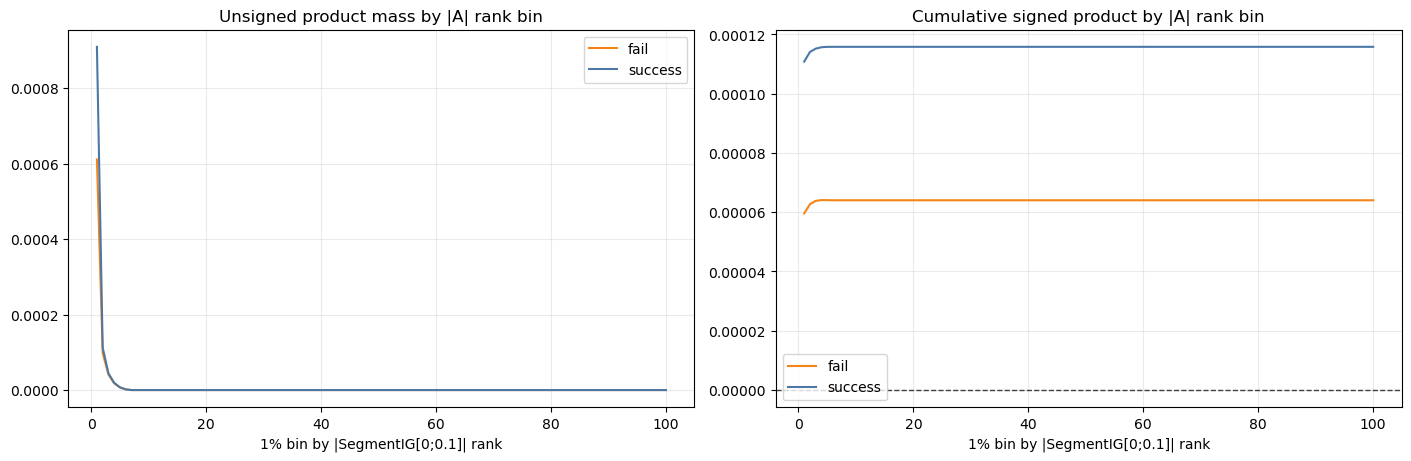

In [9]:
mass = diag_bin_df.pivot_table(index=['path', 'success'], columns='bin', values='unsigned_sum_norm_delta').fillna(0).sort_index(axis=1)
total_mass = mass.sum(axis=1).replace(0, np.nan)
rows = []
for k in [1, 2, 3, 5, 10, 25, 50, 100]:
    frac = (mass.loc[:, :k].sum(axis=1) / total_mass).reset_index(name='mass_fraction')
    summary = frac.groupby('success')['mass_fraction'].agg(['mean', 'std']).reset_index()
    summary['top_bins'] = k
    rows.append(summary)
product_mass_concentration = pd.concat(rows, ignore_index=True)
display(product_mass_concentration.pivot(index='top_bins', columns='success', values='mean').rename(columns={False: 'fail_mean', True: 'success_mean'}))

bin_mean = diag_bin_df.groupby(['success', 'bin'])[['unsigned_sum_norm_delta', 'signed_sum_norm_delta']].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for success, label, color in [(False, 'fail', '#F58518'), (True, 'success', '#4C78A8')]:
    sub = bin_mean[bin_mean['success'] == success]
    axes[0].plot(sub['bin'], sub['unsigned_sum_norm_delta'], label=label, color=color)
    axes[1].plot(sub['bin'], sub['signed_sum_norm_delta'].cumsum(), label=label, color=color)
axes[0].set_title('Unsigned product mass by |A| rank bin')
axes[1].set_title('Cumulative signed product by |A| rank bin')
axes[1].axhline(0, color='0.25', linestyle='--', linewidth=1)
for ax in axes:
    ax.set_xlabel('1% bin by |SegmentIG[0;0.1]| rank')
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()

### 1b. Зачем: посмотреть отдельно на оба множителя product-метрик

Для unsigned product множители — это `|A|` и `|Δ|`. Для signed product — это `-A` и `Δ`, потому что сама метрика считает `(-A) * Δ`. Здесь смотрим, где по рангу `|A|` концентрируются сами множители и где концентрируется их произведение.


abs_importance_mass           abs_delta_mass            \
success                 fail   success           fail   success   
top_bins                                                          
1                   0.748549  0.768956       0.012624  0.021515   
2                   0.892700  0.902587       0.023558  0.038262   
3                   0.955764  0.960129       0.033901  0.053449   
5                   0.996745  0.997085       0.053244  0.080711   
10                  1.000000  1.000000       0.099153  0.128361   
25                  1.000000  1.000000       0.249805  0.274467   
50                  1.000000  1.000000       0.500388  0.519239   
100                 1.000000  1.000000       1.000000  1.000000   

         unsigned_product_mass           abs_signed_product_mass            
success                   fail   success                    fail   success  
top_bins                                                                    
1                     0.792468  0.839017                0.792468  0.839017  
2                     0.915359  0.937295                0.915359  0.937295  
3                     0.966307  0.975766                0.966307  0.975766  
5                     0.997631  0.998428                0.997631  0.998428  
10                    1.000000  1.000000                1.000000  1.000000  
25                    1.000000  1.000000                1.000000  1.000000  
50                    1.000000  1.000000                1.000000  1.000000  
100                   1.000000  1.000000                1.000000  1.000000

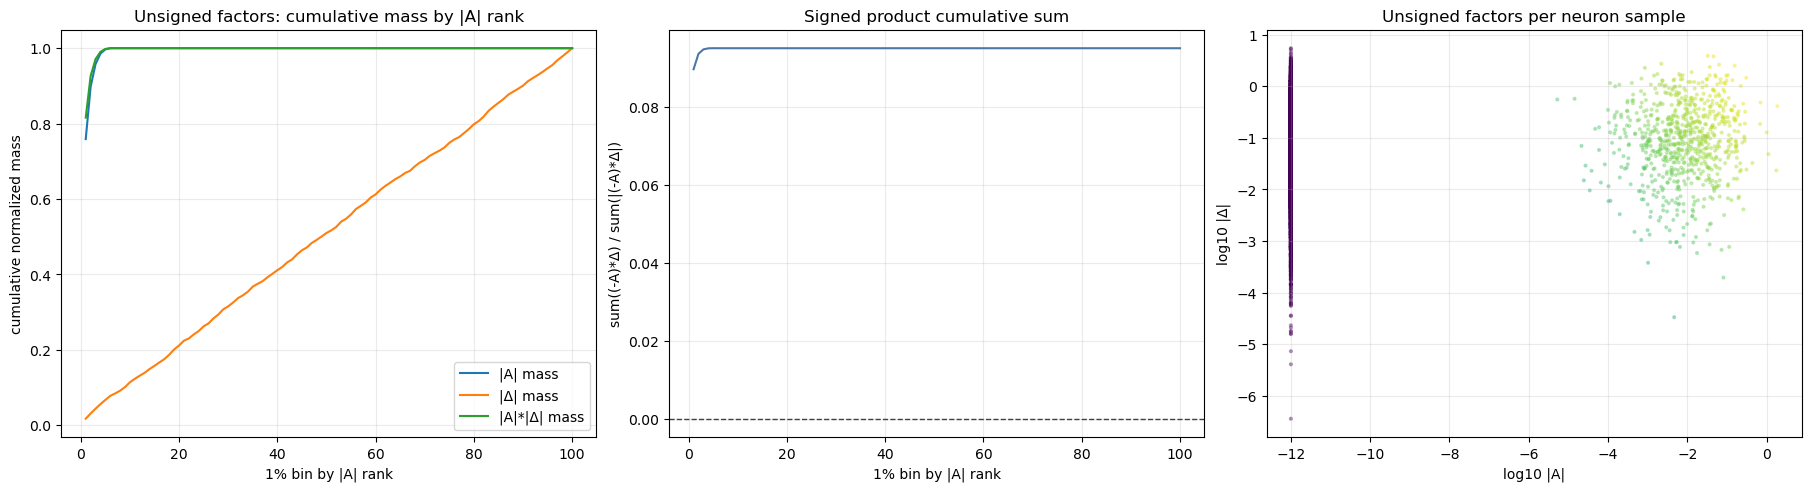

,mean_signed_importance_factor,mean_signed_delta_factor,signed_product_sum_norm_abs
success,,,
fail,-0.000446,-0.018098,0.000600
success,-0.000495,-0.020710,0.001304


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from patch_success_analysis.notebook_setup import resolve_existing_path
factor_examples_per_class = 20
factor_n_bins = 100
factor_examples = pd.concat([
    rows_df[rows_df['success'] == True].head(factor_examples_per_class),
    rows_df[rows_df['success'] == False].head(factor_examples_per_class),
], ignore_index=True)

def _bin_ids_by_abs_importance(importance, n_bins):
    order = np.argsort(-np.abs(importance), kind='mergesort')
    bin_ids = np.empty(order.size, dtype=np.int32)
    for bin_idx, idx in enumerate(np.array_split(order, n_bins)):
        bin_ids[idx] = bin_idx + 1
    return bin_ids

factor_rows = []
scatter_rows = []
rng = np.random.default_rng(17)
for _, row in factor_examples.iterrows():
    with np.load(resolve_existing_path(row['layer_maps_cache_path']), allow_pickle=False) as data:
        a = data['segmentig_chw'].astype('float32', copy=False).reshape(-1)
        d = data['delta_chw'].astype('float32', copy=False).reshape(-1)
    n = min(a.size, d.size)
    a = a[:n]
    d = d[:n]
    a_abs = np.abs(a)
    d_abs = np.abs(d)
    unsigned = a_abs * d_abs
    signed = (-a) * d
    bin_ids = _bin_ids_by_abs_importance(a, factor_n_bins)
    denom_a = a_abs.sum() + 1e-12
    denom_d = d_abs.sum() + 1e-12
    denom_unsigned = unsigned.sum() + 1e-12
    denom_signed_abs = np.abs(signed).sum() + 1e-12
    for bin_idx in range(1, factor_n_bins + 1):
        mask = bin_ids == bin_idx
        factor_rows.append({
            'path': row['path'],
            'success': bool(row['success']),
            'bin': bin_idx,
            'abs_importance_mass': float(a_abs[mask].sum() / denom_a),
            'abs_delta_mass': float(d_abs[mask].sum() / denom_d),
            'unsigned_product_mass': float(unsigned[mask].sum() / denom_unsigned),
            'abs_signed_product_mass': float(np.abs(signed[mask]).sum() / denom_signed_abs),
            'signed_product_sum_norm_abs': float(signed[mask].sum() / denom_signed_abs),
            'mean_signed_importance_factor': float(np.mean((-a)[mask])),
            'mean_signed_delta_factor': float(np.mean(d[mask])),
        })
    sample_n = min(1500, n)
    sample_idx = rng.choice(n, size=sample_n, replace=False)
    scatter_rows.extend({
        'success': bool(row['success']),
        'abs_importance': float(a_abs[idx]),
        'abs_delta': float(d_abs[idx]),
        'signed_importance_factor': float(-a[idx]),
        'signed_delta_factor': float(d[idx]),
        'unsigned_product': float(unsigned[idx]),
        'signed_product': float(signed[idx]),
    } for idx in sample_idx)

factor_bin_df = pd.DataFrame(factor_rows)
factor_scatter_df = pd.DataFrame(scatter_rows)

top_rows = []
for k in [1, 2, 3, 5, 10, 25, 50, 100]:
    sub = factor_bin_df[factor_bin_df['bin'] <= k]
    agg = sub.groupby(['path', 'success'])[[
        'abs_importance_mass', 'abs_delta_mass', 'unsigned_product_mass', 'abs_signed_product_mass'
    ]].sum().reset_index()
    summary = agg.groupby('success')[[
        'abs_importance_mass', 'abs_delta_mass', 'unsigned_product_mass', 'abs_signed_product_mass'
    ]].mean().reset_index()
    summary['top_bins'] = k
    top_rows.append(summary)
factor_concentration = pd.concat(top_rows, ignore_index=True)
display(factor_concentration.pivot(index='top_bins', columns='success', values=[
    'abs_importance_mass', 'abs_delta_mass', 'unsigned_product_mass', 'abs_signed_product_mass'
]).rename(columns={False: 'fail', True: 'success'}))

factor_mean = factor_bin_df.groupby('bin')[[
    'abs_importance_mass', 'abs_delta_mass', 'unsigned_product_mass', 'abs_signed_product_mass', 'signed_product_sum_norm_abs'
]].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
axes[0].plot(factor_mean['bin'], factor_mean['abs_importance_mass'].cumsum(), label='|A| mass')
axes[0].plot(factor_mean['bin'], factor_mean['abs_delta_mass'].cumsum(), label='|Δ| mass')
axes[0].plot(factor_mean['bin'], factor_mean['unsigned_product_mass'].cumsum(), label='|A|*|Δ| mass')
axes[0].set_title('Unsigned factors: cumulative mass by |A| rank')
axes[0].set_xlabel('1% bin by |A| rank')
axes[0].set_ylabel('cumulative normalized mass')
axes[0].legend()

axes[1].plot(factor_mean['bin'], factor_mean['signed_product_sum_norm_abs'].cumsum(), color='#4C78A8')
axes[1].axhline(0, color='0.25', linestyle='--', linewidth=1)
axes[1].set_title('Signed product cumulative sum')
axes[1].set_xlabel('1% bin by |A| rank')
axes[1].set_ylabel('sum((-A)*Δ) / sum(|(-A)*Δ|)')

plot_sample = factor_scatter_df.sample(min(12000, len(factor_scatter_df)), random_state=17)
axes[2].scatter(
    np.log10(plot_sample['abs_importance'] + 1e-12),
    np.log10(plot_sample['abs_delta'] + 1e-12),
    c=np.log10(plot_sample['unsigned_product'].abs() + 1e-18),
    s=4, alpha=0.35, cmap='viridis',
)
axes[2].set_title('Unsigned factors per neuron sample')
axes[2].set_xlabel('log10 |A|')
axes[2].set_ylabel('log10 |Δ|')
for ax in axes:
    ax.grid(alpha=0.25)
plt.show()

signed_factor_summary = factor_bin_df.groupby('success')[[
    'mean_signed_importance_factor', 'mean_signed_delta_factor', 'signed_product_sum_norm_abs'
]].mean().rename(index={False: 'fail', True: 'success'})
display(signed_factor_summary)


### Вывод 1b

Теперь видно не только сам product, но и его множители. Если `|A| * |Δ|` концентрируется намного быстрее, чем `|A|` и `|Δ|` по отдельности, значит произведение усиливает экстремальные точки: оно выбирает места, где одновременно большой attribution и большая дельта. Для signed-варианта дополнительно видно, что знак зависит от согласованности `-A` и `Δ`, а этот эффект слабее и шумнее простой концентрации magnitude.


### Вывод 1

На текущем диагностическом кэше `|A| * |Δ|` почти полностью сидит в первых рангах: top-1% даёт примерно 82-86% product mass, top-2% — 93-95%, top-5% — около 99.8%. Поэтому произведение важности на дельту не является хорошей soft-версией top-k: оно слишком сильно доверяет экстремальным значениям SegmentIG.


### 2. Зачем: отделить magnitude-сигнал от signed-сигнала

Unsigned product отвечает на вопрос “попала ли дельта в большие `|A|`”, а signed product дополнительно требует правильного направления `-A * Δ > 0`. Если unsigned работает лучше signed, проблема именно в добавлении знака.


signed_product_sum_norm_delta            \
                                 mean       std   
success                                           
fail                         0.000064  0.000085   
success                      0.000116  0.000088   

        unsigned_product_sum_norm_delta           correct_mass_ratio  \
                                   mean       std               mean   
success                                                                
fail                           0.000777  0.000421           0.530004   
success                        0.001095  0.000470           0.565180   

                  correct_minus_wrong_norm            
              std                     mean       std  
success                                               
fail     0.041171                 0.060008  0.082342  
success  0.058862                 0.130360  0.117723

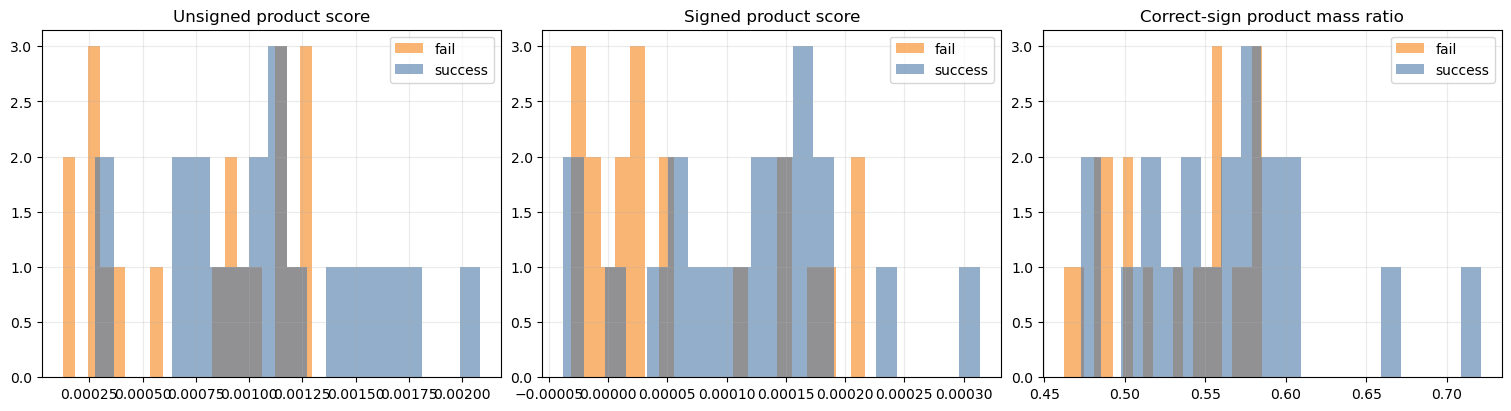

,metric,roc_auc,best_accuracy,best_direction
7,segmentig_delta_energy_in_importance_top,0.848267,0.784167,1
9,segmentig_delta_importance_product_unsigned,0.658305,0.626000,1
8,segmentig_delta_importance_product_signed,0.608056,0.594000,1


In [11]:
decomp_cols = [
    'signed_product_sum_norm_delta',
    'unsigned_product_sum_norm_delta',
    'correct_mass_ratio',
    'correct_minus_wrong_norm',
]
decomp_summary = diag_scalar_df.groupby('success')[decomp_cols].agg(['mean', 'std']).rename(index={False: 'fail', True: 'success'})
display(decomp_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for success, label, color in [(False, 'fail', '#F58518'), (True, 'success', '#4C78A8')]:
    sub = diag_scalar_df[diag_scalar_df['success'] == success]
    axes[0].hist(sub['unsigned_product_sum_norm_delta'], bins=20, alpha=0.6, label=label, color=color)
    axes[1].hist(sub['signed_product_sum_norm_delta'], bins=20, alpha=0.6, label=label, color=color)
    axes[2].hist(sub['correct_mass_ratio'], bins=20, alpha=0.6, label=label, color=color)
axes[0].set_title('Unsigned product score')
axes[1].set_title('Signed product score')
axes[2].set_title('Correct-sign product mass ratio')
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()

quality_focus = quality_df[quality_df['metric'].isin([
    'segmentig_delta_importance_product_signed',
    'segmentig_delta_importance_product_unsigned',
    'segmentig_delta_energy_in_importance_top',
])][['metric', 'roc_auc', 'best_accuracy', 'best_direction']]
display(quality_focus)

### Вывод 2

Unsigned product уже заметно слабее top-k, но signed ещё хуже: на полном кэше ROC-AUC примерно 0.750 для unsigned product и 0.716 для signed product против 0.900 у `delta_energy_in_importance_top`. Correct-sign mass у success выше, но разница небольшая: около 0.55 против 0.49. Значит знак добавляет слабый и шумный сигнал.


### 3. Зачем: проверить две половины signed-гипотезы отдельно

Signed-гипотеза требует двух вещей: для `A > 0` дельта должна чаще быть отрицательной, а для `A < 0` — положительной. Если одна половина не выполняется, общий `-A * Δ` размывается.


pos_importance_correct_fraction            \
                                   mean       std   
success                                             
fail                           0.538184  0.016856   
success                        0.525718  0.017531   

        neg_importance_correct_fraction           pos_importance_mean_delta  \
                                   mean       std                      mean   
success                                                                       
fail                           0.463569  0.017875                 -0.024828   
success                        0.483910  0.017894                 -0.043967   

                  neg_importance_mean_delta            
              std                      mean       std  
success                                                
fail     0.021975                 -0.016584  0.017260  
success  0.016668                 -0.023832  0.017178

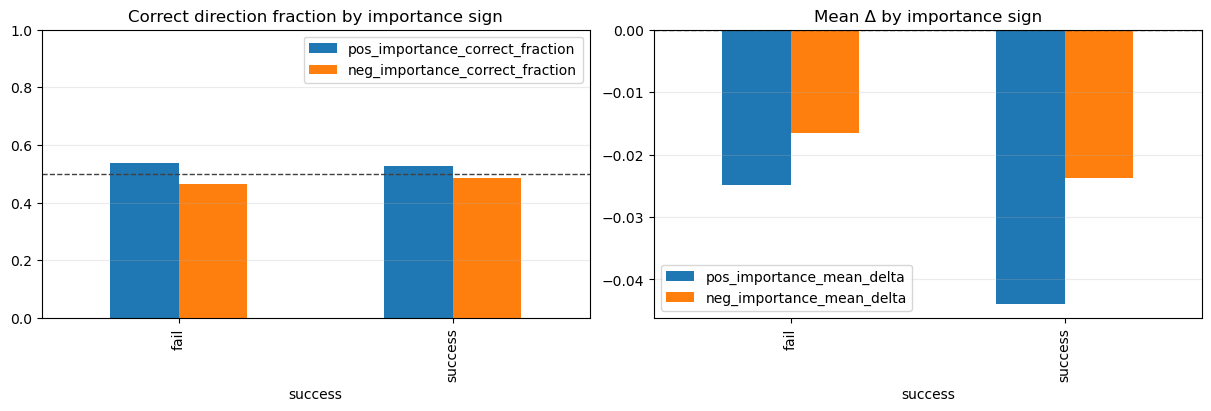

In [12]:
sign_split_cols = [
    'pos_importance_correct_fraction',
    'neg_importance_correct_fraction',
    'pos_importance_mean_delta',
    'neg_importance_mean_delta',
]
sign_split_summary = diag_scalar_df.groupby('success')[sign_split_cols].agg(['mean', 'std']).rename(index={False: 'fail', True: 'success'})
display(sign_split_summary)

plot_summary = diag_scalar_df.groupby('success')[sign_split_cols].mean().rename(index={False: 'fail', True: 'success'})
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
plot_summary[['pos_importance_correct_fraction', 'neg_importance_correct_fraction']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Correct direction fraction by importance sign')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='0.25', linestyle='--', linewidth=1)
plot_summary[['pos_importance_mean_delta', 'neg_importance_mean_delta']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Mean Δ by importance sign')
axes[1].axhline(0, color='0.25', linestyle='--', linewidth=1)
for ax in axes:
    ax.grid(axis='y', alpha=0.25)
plt.show()

### Вывод 3

На текущем кэше signed-гипотеза не выполняется симметрично. Для `A > 0` success не чаще даёт правильное направление, чем fail; для `A < 0` есть только небольшой плюс. Поэтому общий signed product смешивает слабые и частично противоречивые эффекты.


## Handcrafted feature selection

Этот блок использует все одиночные scalar-признаки из `sf["rows"]`: handcrafted features из карт `Δ` и `SegmentIG[0;0.1]`, alignment/spread метрики, product-метрики, ratio-метрики и 1%-bin profile. Split фиксированный: 100 success + 100 fail в train и 100 success + 100 fail в validation.

Важно: здесь больше не перебираем искусственные суммы и разности вида `z(a) + z(b)` / `z(a) - z(b)`. Если метрика сама по себе является произведением или отношением и уже посчитана в `sf["rows"]`, она остаётся как обычный одиночный кандидат.


examples=6000, features=175, train=2000 (1000 success / 1000 fail), val=2000 (1000 success / 1000 fail)


,name,family,formula,cv_acc,cv_acc_std,cv_auc,train_best_acc,val_acc,val_auc,direction,threshold
0,segmentig_hand_spatial_top10_jaccard,single,segmentig_hand_spatial_top10_jaccard,0.793675,0.018246,0.858553,0.7955,0.8045,0.868588,1,0.045796
1,segmentig_align_top_jaccard,single,segmentig_align_top_jaccard,0.790150,0.017381,0.853570,0.7935,0.7920,0.853861,1,0.041895
2,segmentig_hand_overlap_top5_jaccard,single,segmentig_hand_overlap_top5_jaccard,0.790150,0.017381,0.853570,0.7935,0.7920,0.853861,1,0.041895
3,segmentig_hand_overlap_top3_jaccard,single,segmentig_hand_overlap_top3_jaccard,0.786125,0.017217,0.859797,0.7895,0.7935,0.854928,1,0.031955
4,segmentig_delta_energy_importance_bins_top25_exp,single,segmentig_delta_energy_importance_bins_top25_exp,0.785050,0.018865,0.845006,0.7865,0.7930,0.849283,1,0.085840
5,segmentig_delta_energy_in_importance_top,single,segmentig_delta_energy_in_importance_top,0.784850,0.018960,0.846644,0.7870,0.7890,0.850168,1,0.066569
6,segmentig_hand_overlap_top5_delta_in_topA,single,segmentig_hand_overlap_top5_delta_in_topA,0.784850,0.018960,0.846644,0.7870,0.7890,0.850168,1,0.066569
7,segmentig_hand_rank_top5_delta_frac,single,segmentig_hand_rank_top5_delta_frac,0.784850,0.018960,0.846638,0.7870,0.7890,0.850189,1,0.066569
8,segmentig_delta_energy_importance_bins_top10_l...,single,segmentig_delta_energy_importance_bins_top10_l...,0.781750,0.019113,0.844300,0.7850,0.7865,0.848371,1,0.067850
9,segmentig_hand_rank_top6_delta_frac,single,segmentig_hand_rank_top6_delta_frac,0.781600,0.019933,0.844848,0.7860,0.7910,0.850118,1,0.077514


,name,family,formula,cv_acc,cv_acc_std,cv_auc,train_best_acc,val_acc,val_auc,direction,threshold
0,segmentig_hand_spatial_top10_jaccard,single,segmentig_hand_spatial_top10_jaccard,0.793675,0.018246,0.858553,0.7955,0.8045,0.868588,1,0.045796
3,segmentig_hand_overlap_top3_jaccard,single,segmentig_hand_overlap_top3_jaccard,0.786125,0.017217,0.859797,0.7895,0.7935,0.854928,1,0.031955
4,segmentig_delta_energy_importance_bins_top25_exp,single,segmentig_delta_energy_importance_bins_top25_exp,0.785050,0.018865,0.845006,0.7865,0.7930,0.849283,1,0.085840
14,segmentig_delta_energy_importance_bins_top50_exp,single,segmentig_delta_energy_importance_bins_top50_exp,0.776825,0.019068,0.843740,0.7815,0.7925,0.848891,1,0.155642
11,segmentig_hand_overlap_top10_delta_in_topA,single,segmentig_hand_overlap_top10_delta_in_topA,0.778700,0.019025,0.840320,0.7820,0.7925,0.842127,1,0.113562
1,segmentig_align_top_jaccard,single,segmentig_align_top_jaccard,0.790150,0.017381,0.853570,0.7935,0.7920,0.853861,1,0.041895
2,segmentig_hand_overlap_top5_jaccard,single,segmentig_hand_overlap_top5_jaccard,0.790150,0.017381,0.853570,0.7935,0.7920,0.853861,1,0.041895
12,segmentig_delta_energy_importance_bins_top100_exp,single,segmentig_delta_energy_importance_bins_top100_exp,0.777575,0.017693,0.843499,0.7800,0.7920,0.848637,1,0.293655
9,segmentig_hand_rank_top6_delta_frac,single,segmentig_hand_rank_top6_delta_frac,0.781600,0.019933,0.844848,0.7860,0.7910,0.850118,1,0.077514
16,segmentig_delta_energy_importance_bins_top25_l...,single,segmentig_delta_energy_importance_bins_top25_l...,0.776625,0.019360,0.842988,0.7815,0.7905,0.848474,1,0.139725


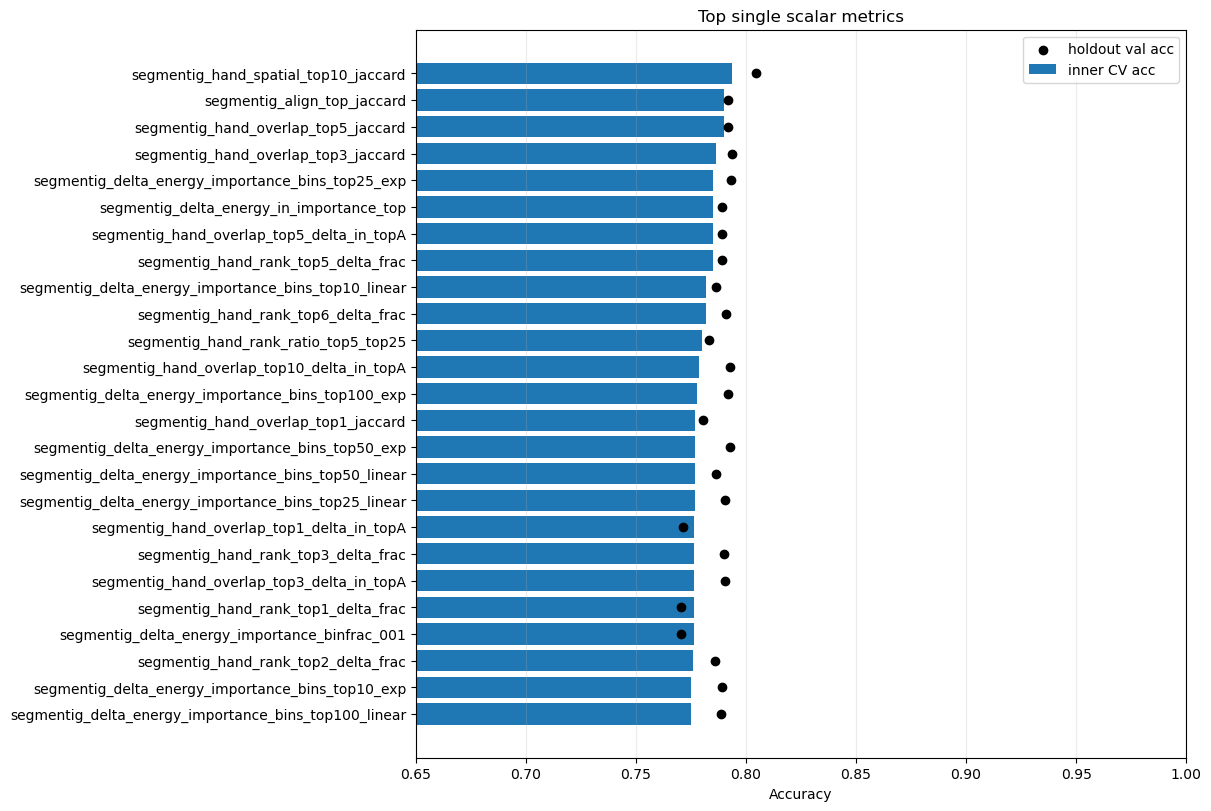

,name,family,formula,cv_acc,cv_acc_std,cv_auc,train_best_acc,val_acc,val_auc,direction,threshold
0,segmentig_hand_spatial_top10_jaccard,single,segmentig_hand_spatial_top10_jaccard,0.793675,0.018246,0.858553,0.7955,0.8045,0.868588,1,0.045796
1,segmentig_align_top_jaccard,single,segmentig_align_top_jaccard,0.790150,0.017381,0.853570,0.7935,0.7920,0.853861,1,0.041895
2,segmentig_hand_overlap_top5_jaccard,single,segmentig_hand_overlap_top5_jaccard,0.790150,0.017381,0.853570,0.7935,0.7920,0.853861,1,0.041895
3,segmentig_hand_overlap_top3_jaccard,single,segmentig_hand_overlap_top3_jaccard,0.786125,0.017217,0.859797,0.7895,0.7935,0.854928,1,0.031955
4,segmentig_delta_energy_importance_bins_top25_exp,single,segmentig_delta_energy_importance_bins_top25_exp,0.785050,0.018865,0.845006,0.7865,0.7930,0.849283,1,0.085840
...,...,...,...,...,...,...,...,...,...,...,...
170,layer_maps_loaded_from_cache,single,layer_maps_loaded_from_cache,0.509500,0.010559,0.490500,0.5095,0.4985,0.501500,-1,0.500000
171,segmentig_delta_energy_importance_binfrac_022,single,segmentig_delta_energy_importance_binfrac_022,0.505950,0.019032,0.492913,0.5250,0.5260,0.490792,-1,0.005781
172,segmentig_delta_energy_importance_binfrac_047,single,segmentig_delta_energy_importance_binfrac_047,0.504050,0.015964,0.500675,0.5240,0.4920,0.528091,-1,0.011424
173,segmentig_delta_energy_importance_binfrac_050,single,segmentig_delta_energy_importance_binfrac_050,0.503575,0.014540,0.488793,0.5235,0.5355,0.471670,-1,0.009511


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold

from patch_success_analysis.metrics import best_accuracy, roc_auc_score_manual

selection_random_state = 31
selection_examples_per_class = 1000
selection_cv_splits = 5
selection_cv_repeats = 20
# Берём только одиночные scalar-кандидаты. Готовые product/ratio признаки уже входят в feature_cols.

rows_df = pd.DataFrame(sf['rows'])
y = rows_df['success'].astype(bool).to_numpy()
exclude_cols = {'success', 'path', 'conf_clean', 'conf_patch', 'drop'}
feature_cols = []
for col in rows_df.columns:
    if col in exclude_cols:
        continue
    if not pd.api.types.is_numeric_dtype(rows_df[col]):
        continue
    values = rows_df[col].astype('float64').to_numpy()
    if np.isfinite(values).all() and np.nanstd(values) > 1e-12:
        feature_cols.append(col)

rng = np.random.default_rng(selection_random_state)
success_idx = np.flatnonzero(y)
fail_idx = np.flatnonzero(~y)
rng.shuffle(success_idx)
rng.shuffle(fail_idx)
needed_per_class = 2 * selection_examples_per_class
if success_idx.size < needed_per_class or fail_idx.size < needed_per_class:
    raise RuntimeError(
        f'Need at least {needed_per_class} success and {needed_per_class} fail examples in sf rows '
        f'to build 100/100 train and 100/100 val; got success={success_idx.size}, fail={fail_idx.size}. '
        'Increase n_success/n_fail and recompute sf with force=True.'
    )
train_idx = np.concatenate([
    success_idx[:selection_examples_per_class],
    fail_idx[:selection_examples_per_class],
])
val_idx = np.concatenate([
    success_idx[selection_examples_per_class:needed_per_class],
    fail_idx[selection_examples_per_class:needed_per_class],
])
rng.shuffle(train_idx)
rng.shuffle(val_idx)

def _eval_with_train_threshold(train_scores, train_y, eval_scores, eval_y):
    best = best_accuracy(train_y, train_scores)
    direction = int(best['direction'])
    threshold = float(best['threshold'])
    pred = eval_scores >= threshold if direction == 1 else eval_scores <= threshold
    return {
        'accuracy': float(np.mean(pred == eval_y)),
        'roc_auc': float(roc_auc_score_manual(eval_y, eval_scores)),
        'direction': direction,
        'threshold': threshold,
        'train_best_accuracy': float(best['accuracy']),
    }

def _inner_cv(score):
    cv = RepeatedStratifiedKFold(
        n_splits=selection_cv_splits,
        n_repeats=selection_cv_repeats,
        random_state=17,
    )
    train_scores = score[train_idx]
    train_y = y[train_idx]
    accs, aucs = [], []
    for tr, te in cv.split(train_scores.reshape(-1, 1), train_y):
        res = _eval_with_train_threshold(train_scores[tr], train_y[tr], train_scores[te], train_y[te])
        accs.append(res['accuracy'])
        aucs.append(res['roc_auc'])
    return float(np.mean(accs)), float(np.std(accs)), float(np.mean(aucs))

def _standardize_on_train(values):
    arr = np.asarray(values, dtype='float64')
    mean = float(arr[train_idx].mean())
    std = float(arr[train_idx].std() + 1e-12)
    return (arr - mean) / std

candidates = []
raw_feature_scores = {col: rows_df[col].astype('float64').to_numpy() for col in feature_cols}

def _add_candidate(name, family, score, formula):
    cv_acc, cv_acc_std, cv_auc = _inner_cv(score)
    train_eval = _eval_with_train_threshold(score[train_idx], y[train_idx], score[train_idx], y[train_idx])
    val_eval = _eval_with_train_threshold(score[train_idx], y[train_idx], score[val_idx], y[val_idx])
    candidates.append({
        'name': name,
        'family': family,
        'formula': formula,
        'cv_acc': cv_acc,
        'cv_acc_std': cv_acc_std,
        'cv_auc': cv_auc,
        'train_best_acc': train_eval['train_best_accuracy'],
        'val_acc': val_eval['accuracy'],
        'val_auc': val_eval['roc_auc'],
        'direction': val_eval['direction'],
        'threshold': val_eval['threshold'],
    })

for col, score in raw_feature_scores.items():
    _add_candidate(col, 'single', score, col)

single_ranking = pd.DataFrame(candidates).sort_values(['cv_acc', 'cv_auc'], ascending=False)
selection_df = single_ranking.reset_index(drop=True)
print(
    f'examples={len(rows_df)}, features={len(feature_cols)}, '
    f'train={len(train_idx)} ({int(y[train_idx].sum())} success / {int((~y[train_idx]).sum())} fail), '
    f'val={len(val_idx)} ({int(y[val_idx].sum())} success / {int((~y[val_idx]).sum())} fail)'
)
display(selection_df.head(30))
display(selection_df.sort_values(['val_acc', 'val_auc'], ascending=False).head(30))

single_best = selection_df.head(25).sort_values('cv_acc')
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.barh(single_best['name'], single_best['cv_acc'], label='inner CV acc')
ax.scatter(single_best['val_acc'], single_best['name'], color='black', zorder=3, label='holdout val acc')
ax.set_xlim(0.65, 1.0)
ax.set_title('Top single scalar metrics')
ax.set_xlabel('Accuracy')
ax.grid(axis='x', alpha=0.25)
ax.legend()
plt.show()

# Keep the selected results in memory for follow-up cells.
selection_df


## Финальное сравнение: новые кандидаты против лучших предыдущих

В конце отдельно сравниваем три лучших одиночных handcrafted/scalar-кандидата с тремя лучшими метриками из предыдущего overall-сравнения. Ранжирование снова только по `val_acc`; `cv_acc` оставляем как диагностический признак, но не используем для порядка на графике.


,group,name,source,weights,train_acc,val_acc,val_auc,cv_acc
0,final handcrafted,segmentig_hand_spatial_top10_jaccard,single,selected formula,0.7955,0.8045,0.868588,0.793675
1,final handcrafted,segmentig_hand_overlap_top3_jaccard,single,selected formula,0.7895,0.7935,0.854928,0.786125
2,final handcrafted,segmentig_delta_energy_importance_bins_top25_exp,single,selected formula,0.7865,0.7930,0.849283,0.785050
3,previous overall,ML: 0.1% bins: top 10% / L2 C=0.001,ML,learned,0.8300,0.7900,0.851900,NaN
4,previous overall,ML: 0.1% bins: top 10% / L2 C=0.003,ML,learned,0.8550,0.7850,0.862200,NaN
5,previous overall,segmentig_hand_spatial_top10_jaccard,precomputed,,0.7850,0.7850,0.844800,NaN


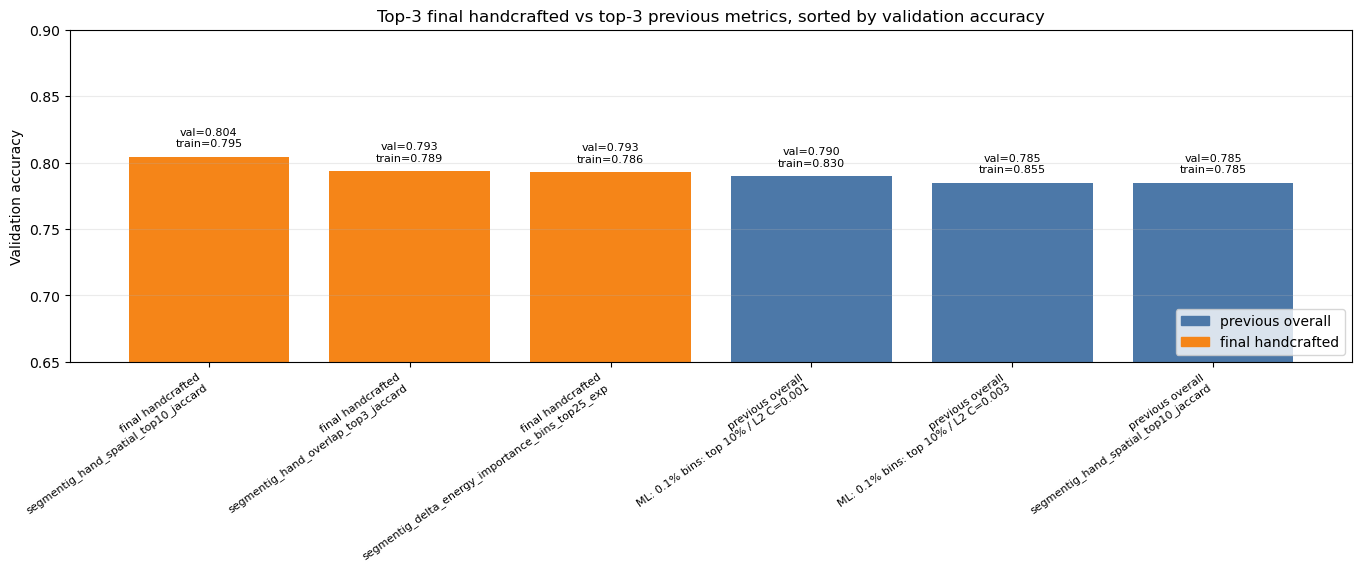

In [22]:
if 'overall_val_df' not in globals():
    raise RuntimeError('Сначала нужно выполнить блок с overall_val_df из секции про 1%/0.1%-бины.')
if 'selection_df' not in globals():
    raise RuntimeError('Сначала нужно выполнить Handcrafted feature selection, чтобы появился selection_df.')

previous_top3 = (
    overall_val_df.sort_values(['val_acc', 'val_auc'], ascending=False)
    .head(3)
    .assign(group='previous overall', cv_acc=np.nan)
    .rename(columns={'method': 'name'})
)
previous_top3 = previous_top3[['group', 'name', 'source', 'weights', 'train_acc', 'val_acc', 'val_auc', 'cv_acc']]

new_top3 = (
    selection_df.sort_values(['val_acc', 'val_auc'], ascending=False)
    .head(3)
    .assign(group='final handcrafted', source=lambda d: d['family'], weights='selected formula')
    .rename(columns={'train_best_acc': 'train_acc'})
)
new_top3 = new_top3[['group', 'name', 'source', 'weights', 'train_acc', 'val_acc', 'val_auc', 'cv_acc']]

top3_comparison_df = (
    pd.concat([previous_top3, new_top3], ignore_index=True)
    .sort_values(['val_acc', 'val_auc'], ascending=False)
    .reset_index(drop=True)
)
display(top3_comparison_df)

fig, ax = plt.subplots(figsize=(13.5, 5.6), constrained_layout=True)
x = np.arange(len(top3_comparison_df))
colors = top3_comparison_df['group'].map({
    'previous overall': '#4C78A8',
    'final handcrafted': '#F58518',
}).fillna('#9D755D').to_numpy()
bars = ax.bar(x, top3_comparison_df['val_acc'], color=colors)
for bar, val, train in zip(bars, top3_comparison_df['val_acc'], top3_comparison_df['train_acc']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.006,
        f'val={val:.3f}\ntrain={train:.3f}',
        ha='center',
        va='bottom',
        fontsize=8,
    )
labels = [
    f"{group}\n{str(name)[:58]}{'...' if len(str(name)) > 58 else ''}"
    for group, name in zip(top3_comparison_df['group'], top3_comparison_df['name'])
]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
ax.set_ylim(0.65, max(0.9, float(top3_comparison_df['val_acc'].max()) + 0.06))
ax.set_title('Top-3 final handcrafted vs top-3 previous metrics, sorted by validation accuracy')
ax.set_ylabel('Validation accuracy')
ax.grid(axis='y', alpha=0.25)
handles = [
    plt.Rectangle((0, 0), 1, 1, color='#4C78A8', label='previous overall'),
    plt.Rectangle((0, 0), 1, 1, color='#F58518', label='final handcrafted'),
]
ax.legend(handles=handles, loc='lower right')
plt.show()
